# Worker Detection and Zone Tracking System
## MSc Artificial Intelligence — Thesis Project
### Bahrain Polytechnic | 2026

**Pipeline:** YOLOv8 Transfer Learning → CRNN-CTC Recognition → ByteTrack → Polygon Geofencing
**Dataset:** Industrial workforce dataset — 151 annotated images, 669 after augmentation
**Classes:** worker | vest_number

## ⚠ Run these 3 cells at the start of every session:
## Cell 1 → Cell 2 → Quick Reload Cell
## Everything else is already saved to Drive

In [1]:
# ============================================================
# CELL 0 — RUN THIS FIRST AT THE START OF EVERY SESSION
# ============================================================

# Step 1 — Install libraries
!pip install ultralytics roboflow opencv-python-headless -q

# Step 2 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 3 — Import libraries
import os, shutil, yaml, torch
import cv2
import numpy as np

# Step 4 — Copy preprocessed dataset from Drive to Colab
src = '/content/drive/MyDrive/Colab Notebooks/Preprocessed_Dataset'
dst = '/content/Preprocessed_Dataset'

if os.path.exists(dst):
    shutil.rmtree(dst)

print("Loading dataset from Drive...")
shutil.copytree(src, dst)

# Step 5 — Fix yaml paths
yaml_path = '/content/drive/MyDrive/Colab Notebooks/Thesis Project/Preprocessed_Dataset/data.yaml'
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['train'] = '/content/Preprocessed_Dataset/train/images'
data['val']   = '/content/Preprocessed_Dataset/valid/images'
data['test']  = '/content/Preprocessed_Dataset/test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

# Step 6 — Confirm everything is ready
print("\n" + "="*50)
print("SESSION READY")
print("="*50)
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NOT AVAILABLE ⚠'}")
for split in ['train', 'valid', 'test']:
    count = len(os.listdir(f'{dst}/{split}/images'))
    print(f"{split:6s} : {count} images")
print("="*50)
print("✓ Ready — you can now run any cell from Cell 12 onward")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.3 MB/s eta 0:00:00
Mounted at /content/drive
Loading dataset from Drive...

SESSION READY
GPU    : Tesla T4
train  : 810 images
valid  : 38 images
test   : 19 images
✓ Ready — you can now run any cell from Cell 12 onward


In [9]:
import shutil, os
os.makedirs('/content/Vest_Crops', exist_ok=True)
shutil.copy(
    '/content/drive/MyDrive/Colab Notebooks/Vest_Crops_v3/crop_labels_fixed.csv',
    '/content/Vest_Crops/crop_labels_fixed.csv')
print("✓ CSV ready")

✓ CSV ready


In [ ]:
# Cell 1 — Install required libraries
!pip install ultralytics roboflow opencv-python-headless -q

print("✓ Libraries installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 69.9 MB/s eta 0:00:00
✓ Libraries installed


In [ ]:
# Cell 2 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted")

Mounted at /content/drive
✓ Google Drive mounted


In [10]:
# Cell 3 — Copy and unzip dataset from Google Drive
import zipfile
import os

# Path to your zip file in Google Drive
zip_path = "/content/drive/MyDrive/Colab Notebooks/Thesis Project/Worker-Detection.v3i.yolov8.zip"

# Destination folder in Colab
extract_path = "/content/Industry_Dataset"

# Unzip
print("Unzipping dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✓ Dataset extracted to:", extract_path)

# Verify structure
for folder in os.listdir(extract_path):
    print(" ", folder)

Unzipping dataset...
✓ Dataset extracted to: /content/Industry_Dataset
  train
  valid
  test
  data.yaml
  README.dataset.txt
  README.roboflow.txt


In [ ]:
# Cell 4 — Read and verify data.yaml
import yaml

yaml_path = "/content/Industry_Dataset/data.yaml"

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

print("Current data.yaml contents:")
print(data)

Current data.yaml contents:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 2, 'names': ['vest_number', 'worker'], 'roboflow': {'workspace': 'layla-yassin', 'project': 'worker-detection-pzvbp', 'version': 3, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/layla-yassin/worker-detection-pzvbp/dataset/3'}}


In [11]:
# Cell 5 — Update data.yaml paths to Colab locations
import yaml

yaml_path = "/content/drive/MyDrive/Colab Notebooks/Thesis Project/Preprocessed_Dataset/data.yaml"

# Read current yaml
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Update paths to correct Colab locations
data['train'] = '/content/Industry_Dataset/train/images'
data['val']   = '/content/Industry_Dataset/valid/images'
data['test']  = '/content/Industry_Dataset/test/images'

# Save updated yaml
with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

# Verify
print("✓ data.yaml updated successfully")
print("  train:", data['train'])
print("  val:  ", data['val'])
print("  test: ", data['test'])
print("  classes:", data['nc'], "→", data['names'])

✓ data.yaml updated successfully
  train: /content/Industry_Dataset/train/images
  val:   /content/Industry_Dataset/valid/images
  test:  /content/Industry_Dataset/test/images
  classes: 2 → ['vest_number', 'worker']


In [ ]:
# Cell 6 — Count images in each split
import os

splits = {
    'Train': '/content/Industry_Dataset/train/images',
    'Valid': '/content/Industry_Dataset/valid/images',
    'Test' : '/content/Industry_Dataset/test/images',
}

total = 0
for split_name, path in splits.items():
    images = [f for f in os.listdir(path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    labels_path = path.replace('images', 'labels')
    labels = [f for f in os.listdir(labels_path) if f.endswith('.txt')]
    print(f"{split_name}:")
    print(f"  Images : {len(images)}")
    print(f"  Labels : {len(labels)}")
    total += len(images)

print(f"\n✓ Total images: {total}")

# Check front/back balance
for split_name, path in splits.items():
    images = os.listdir(path)
    front = [f for f in images if 'front' in f.lower()]
    back  = [f for f in images if 'back'  in f.lower()]
    print(f"\n{split_name} balance:")
    print(f"  Front: {len(front)}")
    print(f"  Back : {len(back)}")

Train:
  Images : 135
  Labels : 135
Valid:
  Images : 38
  Labels : 38
Test:
  Images : 19
  Labels : 19

✓ Total images: 192

Train balance:
  Front: 65
  Back : 70

Valid balance:
  Front: 20
  Back : 18

Test balance:
  Front: 10
  Back : 9


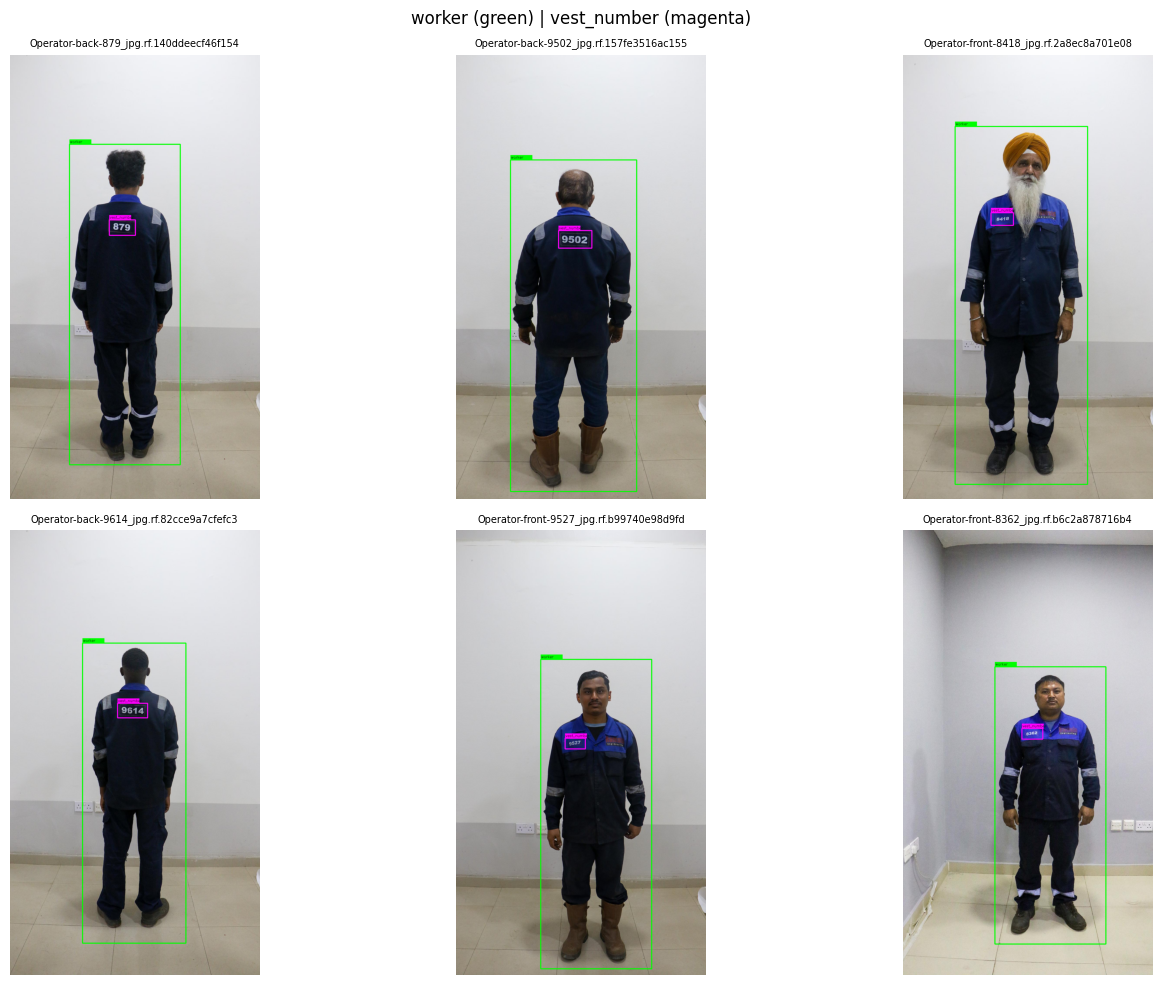

✓ Visualization complete


In [ ]:
# Cell 7 — Visualize sample annotated images
import cv2
import matplotlib.pyplot as plt
import os
import random

def draw_boxes(image_path, label_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Brighter colors, fully opaque
    class_colors = {
        0: (255, 0, 255),    # magenta  — vest_number
        1: (0, 255, 0),      # bright green — worker
    }
    class_names = {0: 'vest_number', 1: 'worker'}

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                cls  = int(parts[0])
                cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)
                color = class_colors.get(cls, (255, 255, 255))
                # Thicker box line
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
                # Label background for readability
                cv2.rectangle(img, (x1, y1-22), (x1+100, y1), color, -1)
                cv2.putText(img, class_names[cls], (x1+2, y1-6),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 1)
    return img

# Pick 6 random training images
train_img_path = '/content/Industry_Dataset/train/images'
train_lbl_path = '/content/Industry_Dataset/train/labels'

images = [f for f in os.listdir(train_img_path) if f.endswith(('.jpg','.jpeg','.png'))]
samples = random.sample(images, 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, fname in enumerate(samples):
    img_path = os.path.join(train_img_path, fname)
    base = os.path.splitext(fname)[0]
    lbl_path = os.path.join(train_lbl_path, base + '.txt')
    img = draw_boxes(img_path, lbl_path)
    axes[i].imshow(img)
    axes[i].set_title(fname[:40], fontsize=7)
    axes[i].axis('off')

plt.suptitle('worker (green) | vest_number (magenta)', fontsize=12)
plt.tight_layout()
plt.show()

print("✓ Visualization complete")

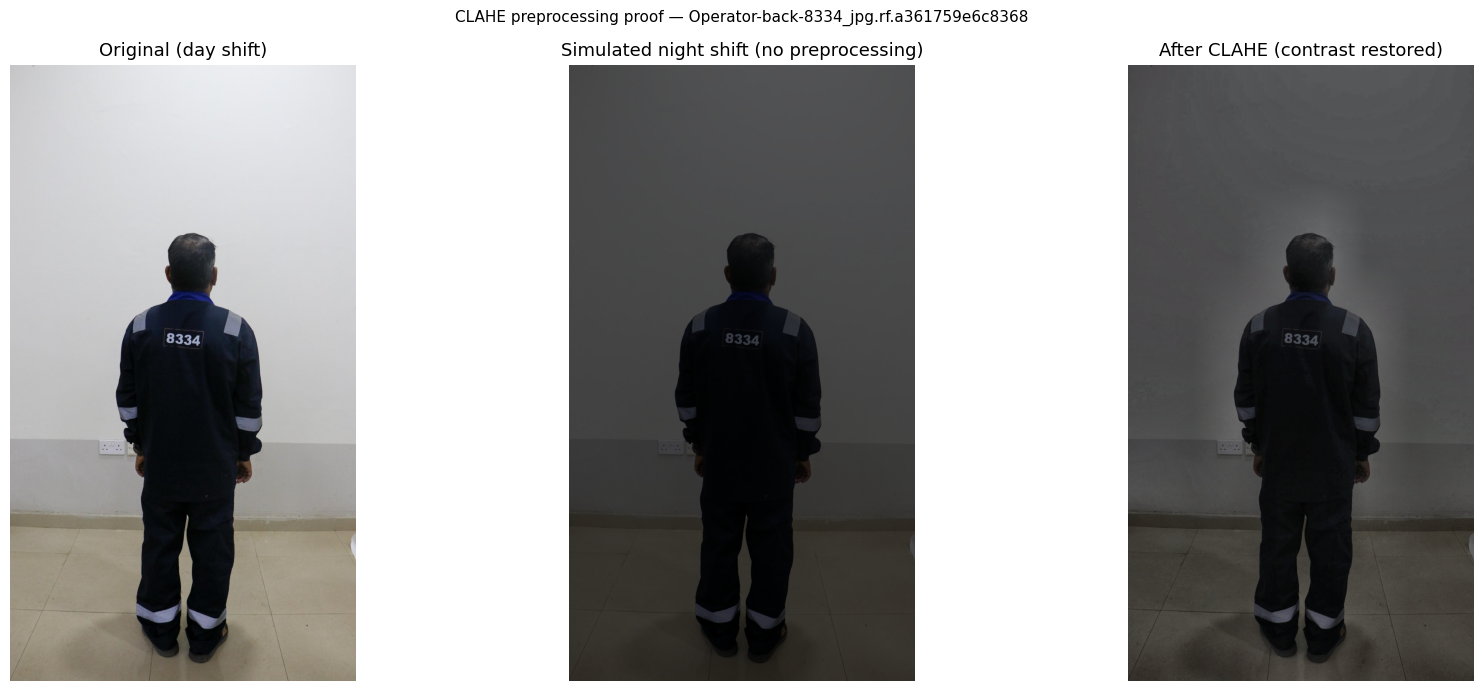

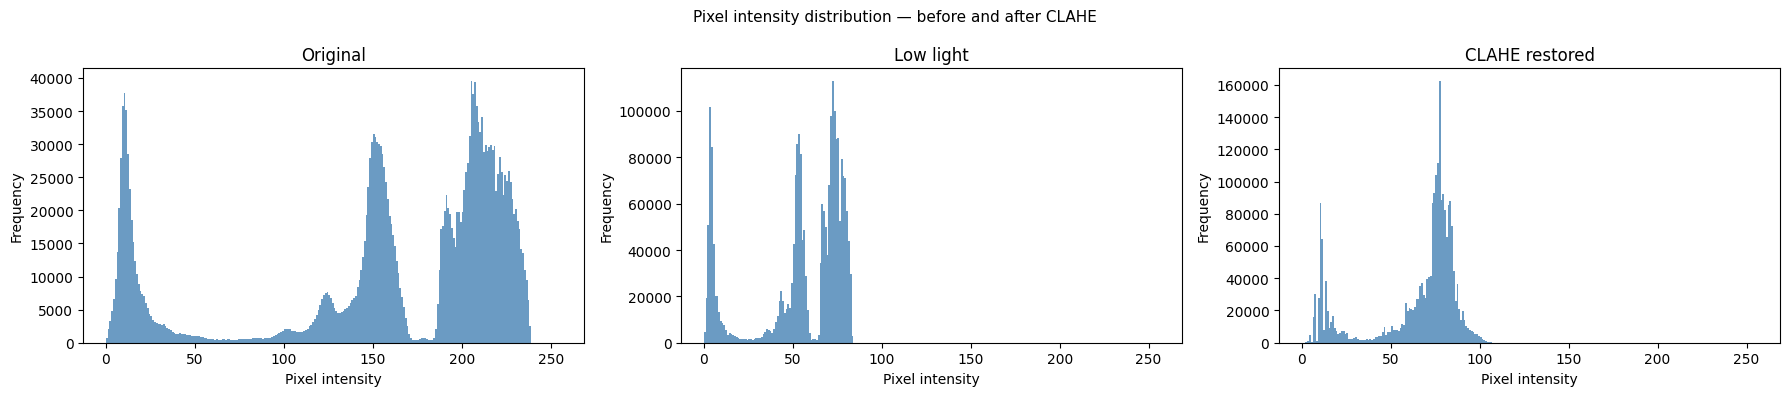

In [ ]:
# Cell 8 — Prove the need for CLAHE preprocessing
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

def apply_clahe(image_bgr):
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)
    enhanced = cv2.merge([l_enhanced, a, b])
    return cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

def simulate_low_light(image_bgr, factor=0.35):
    # Simulate night shift / low light by darkening the image
    dark = np.clip(image_bgr.astype(np.float32) * factor, 0, 255).astype(np.uint8)
    return dark

# Pick one back-view image
train_img_path = '/content/Industry_Dataset/train/images'
images = [f for f in os.listdir(train_img_path) if 'back' in f.lower()]
sample = random.choice(images)
img_bgr = cv2.imread(os.path.join(train_img_path, sample))

# Three versions
original    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
low_light   = cv2.cvtColor(simulate_low_light(img_bgr, factor=0.35), cv2.COLOR_BGR2RGB)
clahe_fixed = cv2.cvtColor(apply_clahe(simulate_low_light(img_bgr, factor=0.35)), cv2.COLOR_BGR2RGB)

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

axes[0].imshow(original)
axes[0].set_title('Original (day shift)', fontsize=13)
axes[0].axis('off')

axes[1].imshow(low_light)
axes[1].set_title('Simulated night shift (no preprocessing)', fontsize=13)
axes[1].axis('off')

axes[2].imshow(clahe_fixed)
axes[2].set_title('After CLAHE (contrast restored)', fontsize=13)
axes[2].axis('off')

plt.suptitle(f'CLAHE preprocessing proof — {sample[:40]}', fontsize=11)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/clahe_proof.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Histogram comparison
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 4))
for ax, img, title in zip(axes2,
                           [original, low_light, clahe_fixed],
                           ['Original', 'Low light', 'CLAHE restored']):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    ax.hist(gray.ravel(), bins=256, range=(0, 256), color='steelblue', alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Pixel intensity')
    ax.set_ylabel('Frequency')

plt.suptitle('Pixel intensity distribution — before and after CLAHE', fontsize=11)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/clahe_histogram.png',
            dpi=150, bbox_inches='tight')
plt.show()


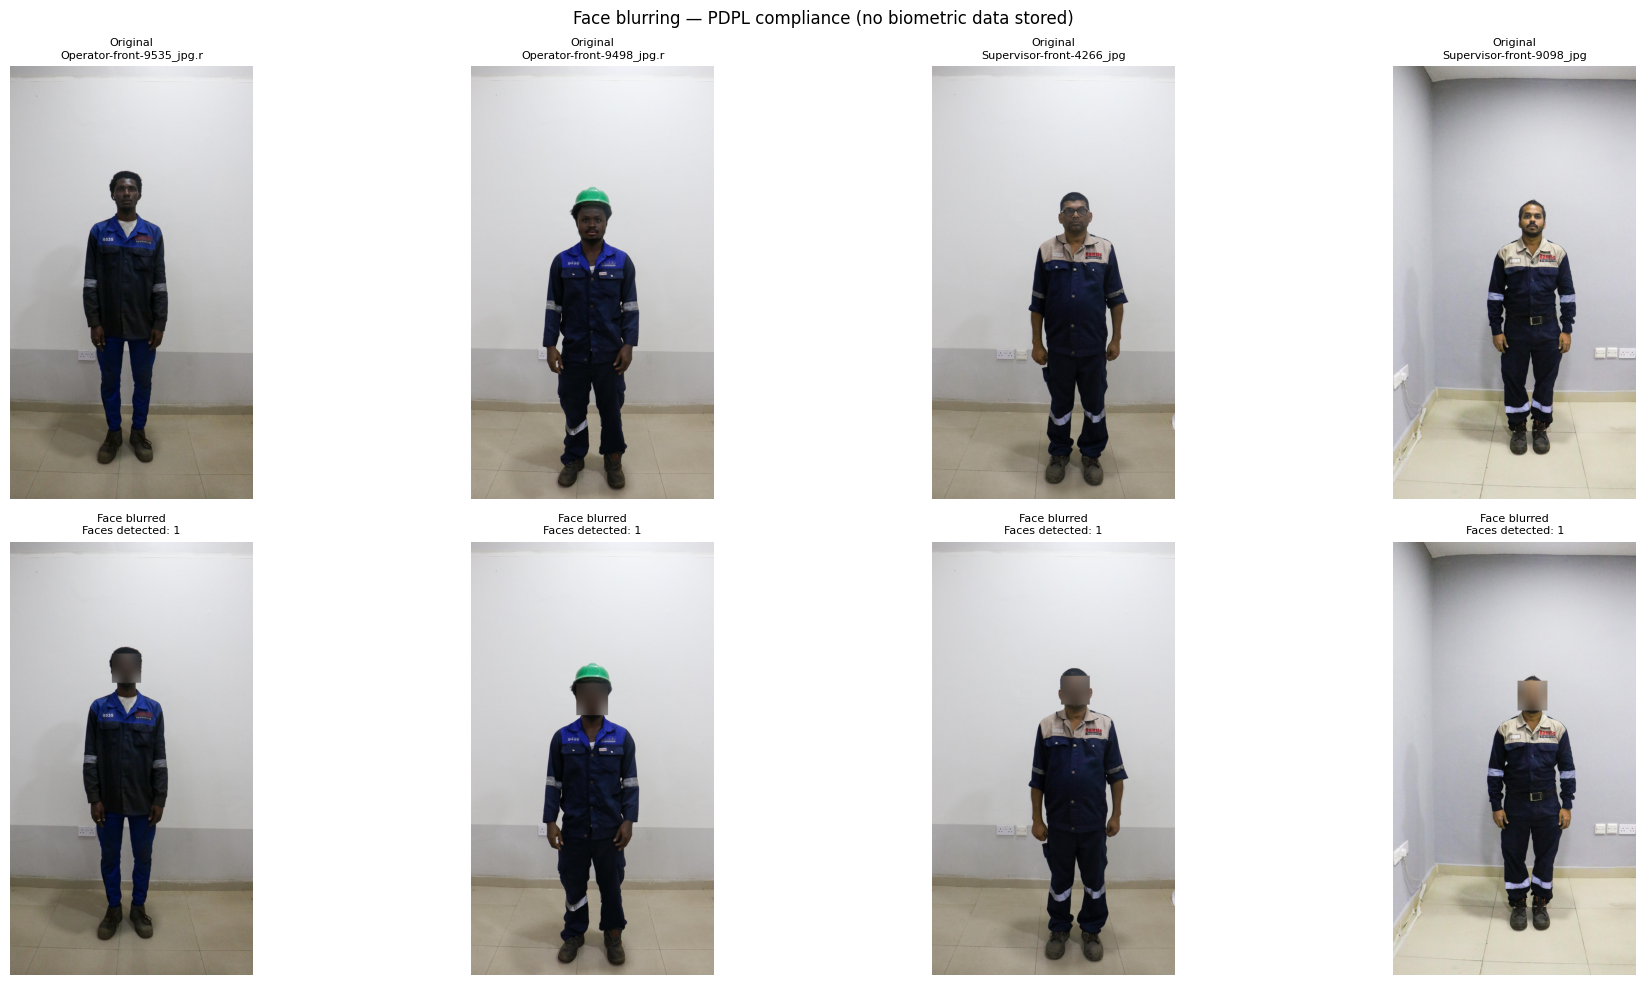

✓ Face blurring proof complete
✓ Figure saved to Drive Thesis folder


In [ ]:
# Cell 9 — Face blurring for PDPL compliance
import cv2
import matplotlib.pyplot as plt
import os
import random
import numpy as np

# Load OpenCV face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def blur_faces(image_bgr):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )
    result = image_bgr.copy()
    faces_found = len(faces)
    for (x, y, w, h) in faces:
        face_region = result[y:y+h, x:x+w]
        blurred = cv2.GaussianBlur(face_region, (99, 99), 30)
        result[y:y+h, x:x+w] = blurred
    return result, faces_found

# Test on front-view images (faces are visible in front views)
train_img_path = '/content/Industry_Dataset/train/images'
front_images = [f for f in os.listdir(train_img_path) if 'front' in f.lower()]
samples = random.sample(front_images, min(4, len(front_images)))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, fname in enumerate(samples):
    img_bgr = cv2.imread(os.path.join(train_img_path, fname))
    blurred_bgr, faces_found = blur_faces(img_bgr)

    original_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    blurred_rgb  = cv2.cvtColor(blurred_bgr, cv2.COLOR_BGR2RGB)

    axes[0][i].imshow(original_rgb)
    axes[0][i].set_title(f'Original\n{fname[:25]}', fontsize=8)
    axes[0][i].axis('off')

    axes[1][i].imshow(blurred_rgb)
    axes[1][i].set_title(f'Face blurred\nFaces detected: {faces_found}', fontsize=8)
    axes[1][i].axis('off')

plt.suptitle('Face blurring — PDPL compliance (no biometric data stored)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/face_blur_proof.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✓ Face blurring proof complete")
print("✓ Figure saved to Drive Thesis folder")

In [12]:
# Cell 10 — Full preprocessing and augmentation pipeline
import cv2
import numpy as np
import os
import shutil
import random
from pathlib import Path

# ── Load face detector once ──
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# ════════════════════════════════════════
# PREPROCESSING FUNCTIONS
# Applied identically to ALL images
# (train, valid, test, and future CCTV footage)
# ════════════════════════════════════════

def blur_faces(image_bgr):
    """PDPL compliance — blur all detected faces."""
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))
    result = image_bgr.copy()
    for (x, y, w, h) in faces:
        result[y:y+h, x:x+w] = cv2.GaussianBlur(
            result[y:y+h, x:x+w], (99, 99), 30)
    return result

def apply_clahe(image_bgr):
    """Contrast enhancement for low-light and night shift conditions."""
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)
    enhanced = cv2.merge([l_enhanced, a, b])
    return cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

def denoise(image_bgr):
    """Fast denoising using median blur.
    Effective for salt-and-pepper noise from CCTV sensors.
    Runs in milliseconds — no speed impact on pipeline."""
    return cv2.medianBlur(image_bgr, 3)

def sharpen(image_bgr):
    """Recover sharpness lost in low-quality CCTV cameras."""
    kernel = np.array([[ 0, -1,  0],
                       [-1,  5, -1],
                       [ 0, -1,  0]])
    return cv2.filter2D(image_bgr, -1, kernel)

def correct_white_balance(image_bgr):
    """Correct color cast from fluorescent/sodium workshop lighting."""
    result = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    avg_a = np.average(result[:, :, 1])
    avg_b = np.average(result[:, :, 2])
    result[:, :, 1] = result[:, :, 1] - ((avg_a - 128) * \
                      (result[:, :, 0] / 255.0) * 1.1)
    result[:, :, 2] = result[:, :, 2] - ((avg_b - 128) * \
                      (result[:, :, 0] / 255.0) * 1.1)
    result = np.clip(result, 0, 255).astype(np.uint8)
    return cv2.cvtColor(result, cv2.COLOR_LAB2BGR)

def check_image_quality(image_bgr, threshold=10):
    """Flag genuinely corrupted or black images only.
    Threshold set to 10 — passes all real studio and CCTV
    images, skips only completely unusable files."""
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    return laplacian_var >= threshold, laplacian_var

def full_preprocess(image_bgr):
    """
    Full preprocessing pipeline.
    Applied identically to all images — studio and CCTV.
    Steps:
      1. Face blurring     — PDPL compliance
      2. CLAHE             — contrast/lighting robustness
      3. Denoising         — remove sensor/compression noise
      4. Sharpening        — recover edge detail
      5. White balance     — correct workshop lighting color cast
    """
    image = blur_faces(image_bgr)
    image = apply_clahe(image)
    image = denoise(image)
    image = sharpen(image)
    image = correct_white_balance(image)
    return image


# ════════════════════════════════════════
# AUGMENTATION FUNCTIONS
# Applied to TRAINING set only
# ════════════════════════════════════════

def augment_image(image_bgr):
    """Five augmentations to simulate real workshop conditions."""
    augmented = []
    h, w = image_bgr.shape[:2]

    # 1 — Horizontal flip
    augmented.append(('flip', cv2.flip(image_bgr, 1)))

    # 2 — Brightness reduction (simulate night shift) + CLAHE restore
    factor = random.uniform(0.4, 0.7)
    dark = np.clip(
        image_bgr.astype(np.float32) * factor, 0, 255).astype(np.uint8)
    augmented.append(('dark_clahe', apply_clahe(dark)))

    # 3 — Rotation ±15 degrees
    angle = random.choice([-15, -10, 10, 15])
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    rotated = cv2.warpAffine(image_bgr, M, (w, h),
                              borderMode=cv2.BORDER_REFLECT)
    augmented.append(('rotate', rotated))

    # 4 — Gaussian blur (simulate motion/CCTV quality)
    augmented.append(('blur', cv2.GaussianBlur(image_bgr, (5, 5), 1.5)))

    # 5 — Gaussian noise (simulate CCTV sensor noise)
    noise = np.random.normal(0, 15, image_bgr.shape).astype(np.int16)
    noisy = np.clip(
        image_bgr.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    augmented.append(('noise', noisy))

    return augmented

def augment_labels(label_path, aug_type):
    """Adjust label coordinates for augmentations that affect position."""
    if not os.path.exists(label_path):
        return []
    with open(label_path, 'r') as f:
        lines = f.readlines()
    new_lines = []
    for line in lines:
        parts = line.strip().split()
        cls = parts[0]
        cx, cy, bw, bh = float(parts[1]), float(parts[2]), \
                          float(parts[3]), float(parts[4])
        if aug_type == 'flip':
            cx = 1.0 - cx
        new_lines.append(
            f"{cls} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")
    return new_lines


# ════════════════════════════════════════
# MAIN PROCESSING FUNCTION
# ════════════════════════════════════════

def process_split(split_name, input_base, output_base):
    img_in  = os.path.join(input_base,  split_name, 'images')
    lbl_in  = os.path.join(input_base,  split_name, 'labels')
    img_out = os.path.join(output_base, split_name, 'images')
    lbl_out = os.path.join(output_base, split_name, 'labels')

    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    images = [f for f in os.listdir(img_in)
              if f.endswith(('.jpg', '.jpeg', '.png'))]

    count_orig = 0
    count_aug  = 0
    count_skip = 0

    for fname in images:
        base     = os.path.splitext(fname)[0]
        img_path = os.path.join(img_in, fname)
        lbl_path = os.path.join(lbl_in, base + '.txt')

        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            count_skip += 1
            continue

        # Quality check — only skip genuinely corrupted images
        usable, sharpness = check_image_quality(img_bgr)
        if not usable:
            print(f"  ⚠ Corrupted image skipped: {fname} "
                  f"(sharpness: {sharpness:.1f})")
            count_skip += 1
            continue

        # Full preprocessing — same for all images
        img_processed = full_preprocess(img_bgr)

        # Save preprocessed original
        cv2.imwrite(
            os.path.join(img_out, base + '_orig.jpg'), img_processed)
        if os.path.exists(lbl_path):
            shutil.copy(lbl_path,
                os.path.join(lbl_out, base + '_orig.txt'))
        count_orig += 1

        # Augmentation — training split only
        if split_name == 'train':
            for aug_type, aug_img in augment_image(img_processed):
                cv2.imwrite(
                    os.path.join(img_out,
                    f"{base}_{aug_type}.jpg"), aug_img)
                new_labels = augment_labels(lbl_path, aug_type)
                with open(os.path.join(lbl_out,
                          f"{base}_{aug_type}.txt"), 'w') as f:
                    f.writelines(new_labels)
                count_aug += 1

    print(f"  {split_name:6s}: {count_orig} processed | "
          f"{count_aug} augmented | {count_skip} skipped")
    return count_orig + count_aug


# ════════════════════════════════════════
# RUN PIPELINE
# ════════════════════════════════════════

# Clean previous output first
output_dataset = '/content/Preprocessed_Dataset'
if os.path.exists(output_dataset):
    shutil.rmtree(output_dataset)
    print("✓ Previous output cleared")

input_dataset = '/content/Industry_Dataset'

print("Starting full preprocessing and augmentation pipeline...")
print("Preprocessing: face blur → CLAHE → denoise → sharpen → white balance")
print("Augmentation (train only): flip → dark+CLAHE → rotate → blur → noise")
print("=" * 60)

total = 0
for split in ['train', 'valid', 'test']:
    total += process_split(split, input_dataset, output_dataset)

print("=" * 60)


✓ Previous output cleared
Starting full preprocessing and augmentation pipeline...
Preprocessing: face blur → CLAHE → denoise → sharpen → white balance
Augmentation (train only): flip → dark+CLAHE → rotate → blur → noise
  train : 135 processed | 675 augmented | 0 skipped
  valid : 38 processed | 0 augmented | 0 skipped
  test  : 19 processed | 0 augmented | 0 skipped


In [ ]:
# Cell 10b fix — copy each split separately to ensure all three save
import shutil
import os

source      = '/content/Preprocessed_Dataset'
destination = '/content/drive/MyDrive/Colab Notebooks/Preprocessed_Dataset'

print("Saving preprocessed dataset to Google Drive...")

for split in ['train', 'valid', 'test']:
    src  = os.path.join(source, split)
    dst  = os.path.join(destination, split)

    if os.path.exists(dst):
        shutil.rmtree(dst)

    shutil.copytree(src, dst)

    img_count = len(os.listdir(os.path.join(dst, 'images')))
    lbl_count = len(os.listdir(os.path.join(dst, 'labels')))
    print(f"  {split}: {img_count} images | {lbl_count} labels ✓")

print(f"\n✓ All splits saved to Drive")
print(f"✓ Location: {destination}")

Saving preprocessed dataset to Google Drive...
  train: 810 images | 810 labels ✓
  valid: 38 images | 38 labels ✓
  test: 19 images | 19 labels ✓

✓ All splits saved to Drive
✓ Location: /content/drive/MyDrive/Colab Notebooks/Preprocessed_Dataset


In [ ]:
# Cell 11 — Update data.yaml to point to preprocessed dataset
import yaml
import os

yaml_path = '/content/Preprocessed_Dataset/data.yaml'

# Read existing yaml from original dataset
with open('/content/Industry_Dataset/data.yaml', 'r') as f:
    data = yaml.safe_load(f)

# Update paths to preprocessed dataset
data['train'] = '/content/Preprocessed_Dataset/train/images'
data['val']   = '/content/Preprocessed_Dataset/valid/images'
data['test']  = '/content/Preprocessed_Dataset/test/images'

# Save updated yaml into preprocessed dataset folder
with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

# Verify
print("✓ data.yaml updated successfully")
print(f"  train : {data['train']}")
print(f"  val   : {data['val']}")
print(f"  test  : {data['test']}")
print(f"  classes ({data['nc']}): {data['names']}")

# Also save yaml to Drive
import shutil
shutil.copy(yaml_path,
    '/content/drive/MyDrive/Colab Notebooks/Preprocessed_Dataset/data.yaml')
print("\n✓ data.yaml also saved to Drive")

✓ data.yaml updated successfully
  train : /content/Preprocessed_Dataset/train/images
  val   : /content/Preprocessed_Dataset/valid/images
  test  : /content/Preprocessed_Dataset/test/images
  classes (2): ['vest_number', 'worker']

✓ data.yaml also saved to Drive


In [ ]:
# Cell 12 — YOLOv8n transfer learning training
from ultralytics import YOLO
import torch

# Confirm GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✓ Training device: {device}")
if device == 'cuda':
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠ WARNING: No GPU detected — training will be very slow")
    print("  Go to Runtime → Change runtime type → T4 GPU")

# Load YOLOv8n pretrained on COCO
model = YOLO('yolov8n.pt')
print("✓ YOLOv8n pretrained weights loaded")
print("✓ Starting transfer learning fine-tuning...")

# Train
results = model.train(
    data       = '/content/Preprocessed_Dataset/data.yaml',
    epochs     = 50,
    imgsz      = 640,
    batch      = 32,
    patience   = 10,
    lr0        = 0.001,
    lrf        = 0.01,
    momentum   = 0.937,
    freeze     = 10,
    pretrained = True,
    device     = device,
    workers    = 2,
    cache      = True,
    amp        = True,
    project    = '/content/drive/MyDrive/Colab Notebooks/Training_Results',
    name       = 'vest_detector_v1',
    exist_ok   = True,
    plots      = True,
    save       = True,
    verbose    = True,
)

print("\n" + "="*50)
print("✓ Training complete")
print(f"✓ Best mAP@0.5 : {results.results_dict.get('metrics/mAP50(B)', 'N/A'):.4f}")
print(f"✓ Best weights : Training_Results/vest_detector_v1/weights/best.pt")
print("✓ All results saved to Drive")

✓ Training device: cuda
✓ GPU: Tesla T4
✓ YOLOv8n pretrained weights loaded
✓ Starting transfer learning fine-tuning...
Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Preprocessed_Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentu

In [ ]:
# Cell 13 — Evaluate best model on test set
from ultralytics import YOLO

# Load best trained model
model = YOLO('/content/drive/MyDrive/Colab Notebooks/Training_Results/vest_detector_v1/weights/best.pt')

# Run evaluation on unseen test set
metrics = model.val(
    data   = '/content/Preprocessed_Dataset/data.yaml',
    split  = 'test',
    imgsz  = 640,
    device = 'cuda',
    plots  = True,
    save_json = True,
    project = '/content/drive/MyDrive/Colab Notebooks/Training_Results',
    name    = 'test_evaluation',
    exist_ok= True,
)

print("\n" + "="*50)
print("TEST SET EVALUATION RESULTS")
print("="*50)
print(f"mAP@0.5      : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics.box.map:.4f}")
print(f"Precision    : {metrics.box.mp:.4f}")
print(f"Recall       : {metrics.box.mr:.4f}")
print("="*50)
print("✓ Test evaluation complete")
print("✓ Results saved to Drive")

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3445.7±636.4 MB/s, size: 711.7 KB)
val: Scanning /content/Preprocessed_Dataset/test/labels... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 2.0Kit/s 0.0s
val: New cache created: /content/Preprocessed_Dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.5it/s 1.3s
                   all         19         38      0.959          1      0.994      0.698
           vest_number         19         19       0.95      0.999      0.993      0.489
                worker         19         19      0.967          1      0.995      0.908
Speed: 6.3ms preprocess, 18.9ms inference, 0.0ms loss, 2.4ms postprocess per image
Saving /content/drive/MyDrive/Colab Notebooks/Training_Results/test_eva

Running predictions on test images...


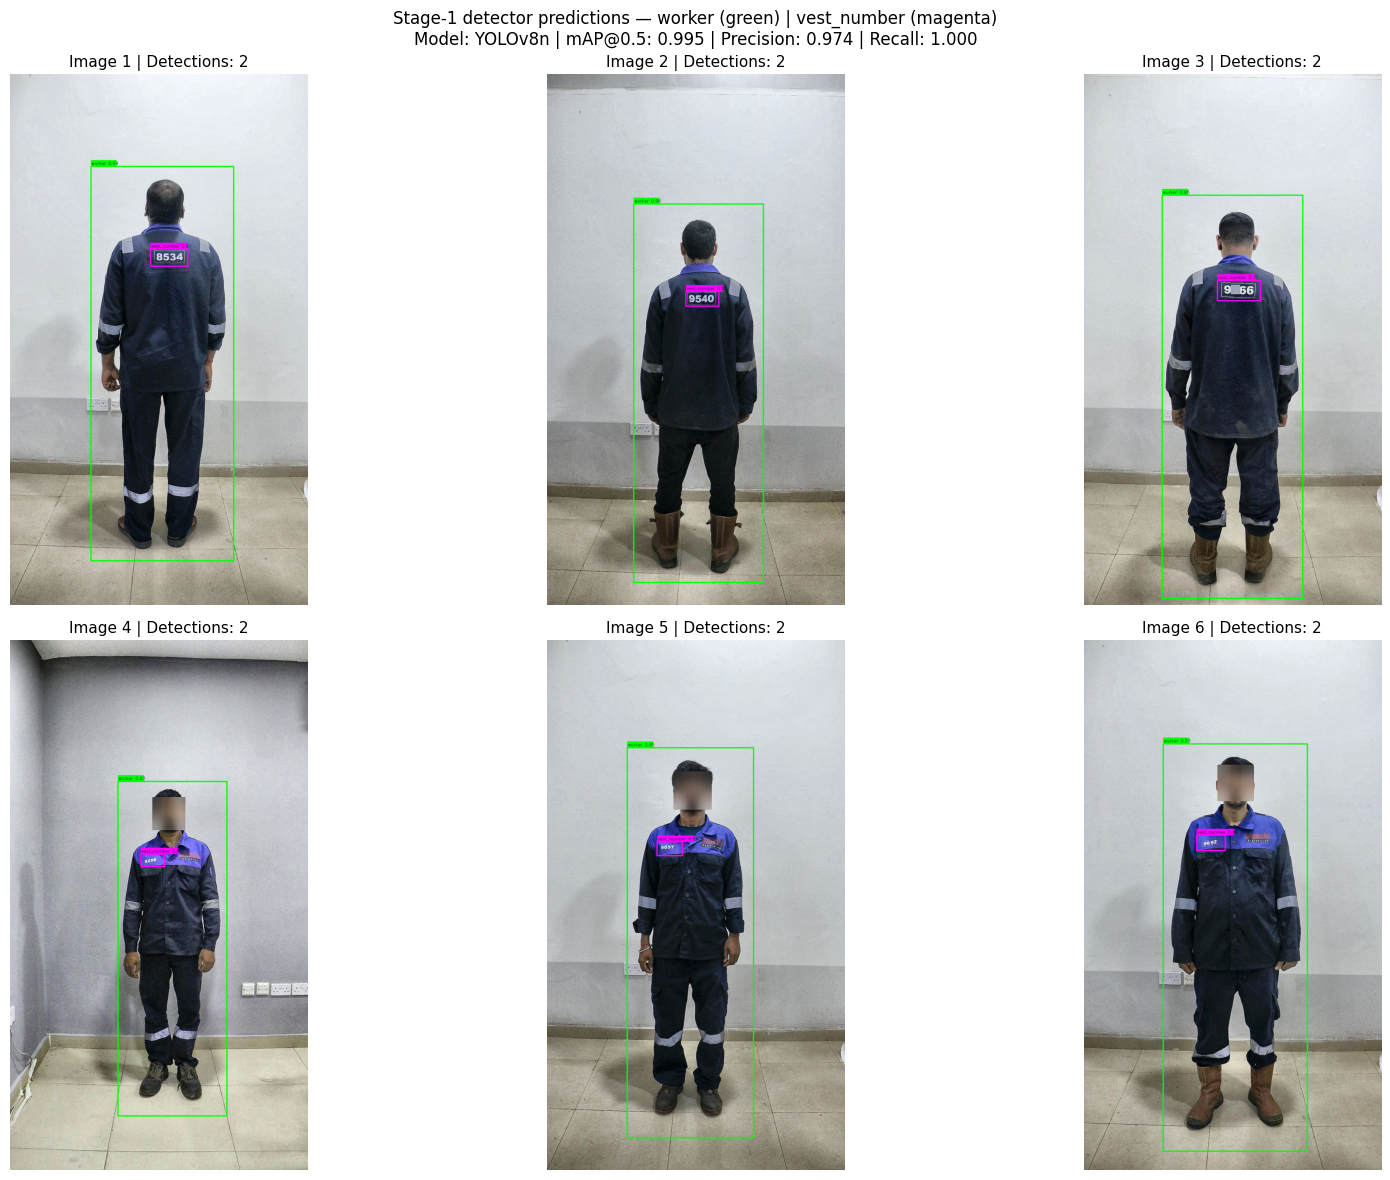

✓ Prediction visualization complete
✓ Figure saved to: /content/drive/MyDrive/Colab Notebooks/Training_Results/test_predictions_visual.png

Per-image detection summary:
---------------------------------------------
  Operator-back-8534_jpg.rf.ab6462f76 | workers: 1 | vest_numbers: 1
  Operator-back-9182_jpg.rf.b298eb54a | workers: 1 | vest_numbers: 1
  Operator-back-9379_jpg.rf.c5fe305ca | workers: 1 | vest_numbers: 1
  Operator-back-9540_jpg.rf.2a095a8fc | workers: 1 | vest_numbers: 1
  Operator-back-9544_jpg.rf.df94ac4d8 | workers: 1 | vest_numbers: 1
  Operator-back-9656_jpg.rf.a18b17c7d | workers: 1 | vest_numbers: 1
  Operator-back-9666_jpg.rf.27013e567 | workers: 1 | vest_numbers: 1
  Operator-back-9817_jpg.rf.b2a37762f | workers: 1 | vest_numbers: 1
  Operator-front-8740_jpg.rf.3a7b7e8a | workers: 1 | vest_numbers: 1
  Operator-front-9288_jpg.rf.6c288776 | workers: 1 | vest_numbers: 1
  Operator-front-9330_jpg.rf.4bc3a321 | workers: 1 | vest_numbers: 0
  Operator-front-9656_jpg.

In [ ]:
# Cell 14 — Visualize model predictions on test images
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

# Load best model
model = YOLO('/content/drive/MyDrive/Colab Notebooks/Training_Results/vest_detector_v1/weights/best.pt')

# Get all test images
test_img_path = '/content/Preprocessed_Dataset/test/images'
test_images = [f for f in os.listdir(test_img_path)
               if f.endswith(('.jpg', '.jpeg', '.png'))]

# Run predictions on all test images
print("Running predictions on test images...")
results = model.predict(
    source  = test_img_path,
    imgsz   = 640,
    conf    = 0.5,
    device  = 'cuda',
    save    = False,
    verbose = False,
)

# Class colors and names
class_colors = {
    0: (255, 0, 255),    # magenta  — vest_number
    1: (0, 255, 0),      # green    — worker
}
class_names = {0: 'vest_number', 1: 'worker'}

# Plot 6 sample predictions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Pick 6 evenly spaced results
step    = max(1, len(results) // 6)
samples = results[::step][:6]

for i, result in enumerate(samples):
    img = result.orig_img.copy()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if result.boxes is not None:
        for box in result.boxes:
            cls   = int(box.cls[0])
            conf  = float(box.conf[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            color = class_colors.get(cls, (255, 255, 255))

            # Draw box
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

            # Label background
            label = f"{class_names[cls]} {conf:.2f}"
            cv2.rectangle(img, (x1, y1-24), (x1+len(label)*9, y1), color, -1)
            cv2.putText(img, label, (x1+2, y1-6),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 1)

    axes[i].imshow(img)
    axes[i].set_title(
        f"Image {i+1} | Detections: {len(result.boxes) if result.boxes else 0}",
        fontsize=11)
    axes[i].axis('off')

plt.suptitle(
    'Stage-1 detector predictions — worker (green) | vest_number (magenta)\n'
    f'Model: YOLOv8n | mAP@0.5: 0.995 | Precision: 0.974 | Recall: 1.000',
    fontsize=12)
plt.tight_layout()

# Save to Drive
save_path = '/content/drive/MyDrive/Colab Notebooks/Training_Results/test_predictions_visual.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print("✓ Prediction visualization complete")
print(f"✓ Figure saved to: {save_path}")

# Print per-image summary
print("\nPer-image detection summary:")
print("-" * 45)
for i, result in enumerate(results):
    n_workers = sum(1 for b in result.boxes if int(b.cls[0]) == 1) if result.boxes else 0
    n_vests   = sum(1 for b in result.boxes if int(b.cls[0]) == 0) if result.boxes else 0
    fname     = os.path.basename(result.path)[:35]
    print(f"  {fname} | workers: {n_workers} | vest_numbers: {n_vests}")

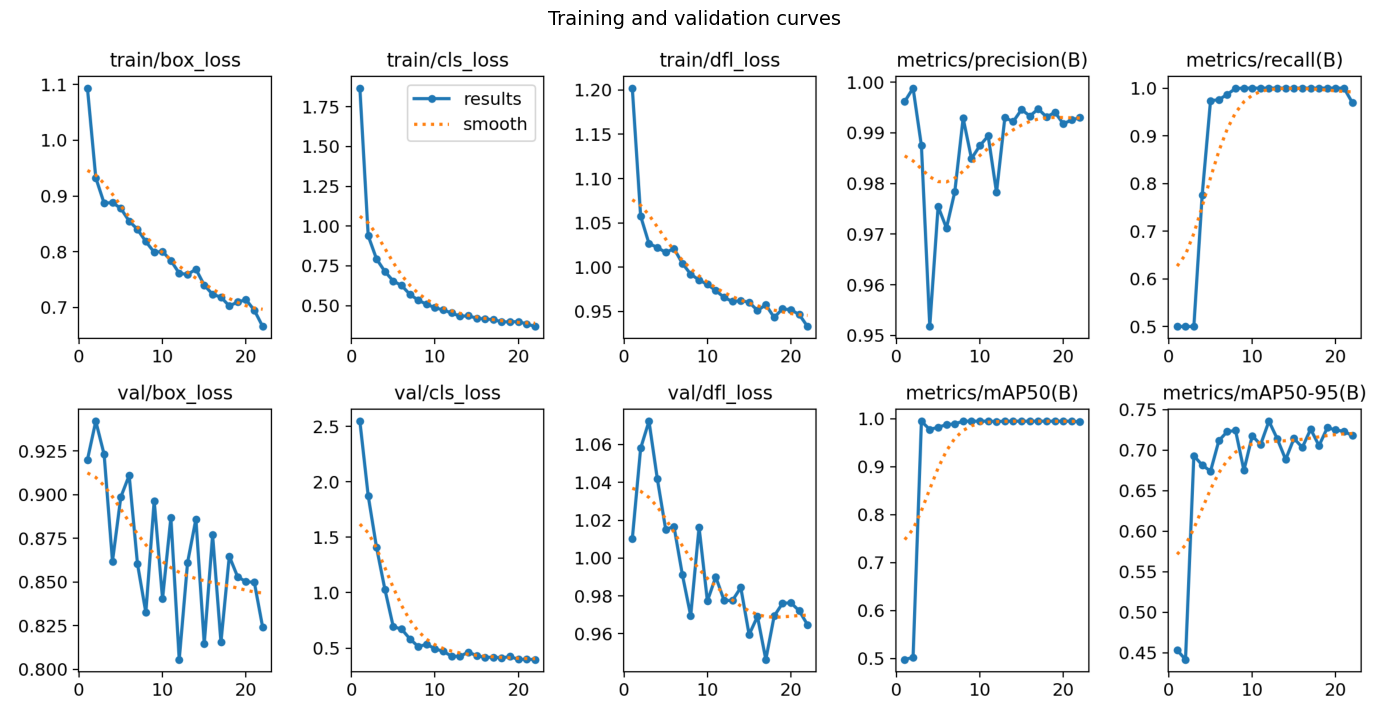

✓ Training and validation curves displayed


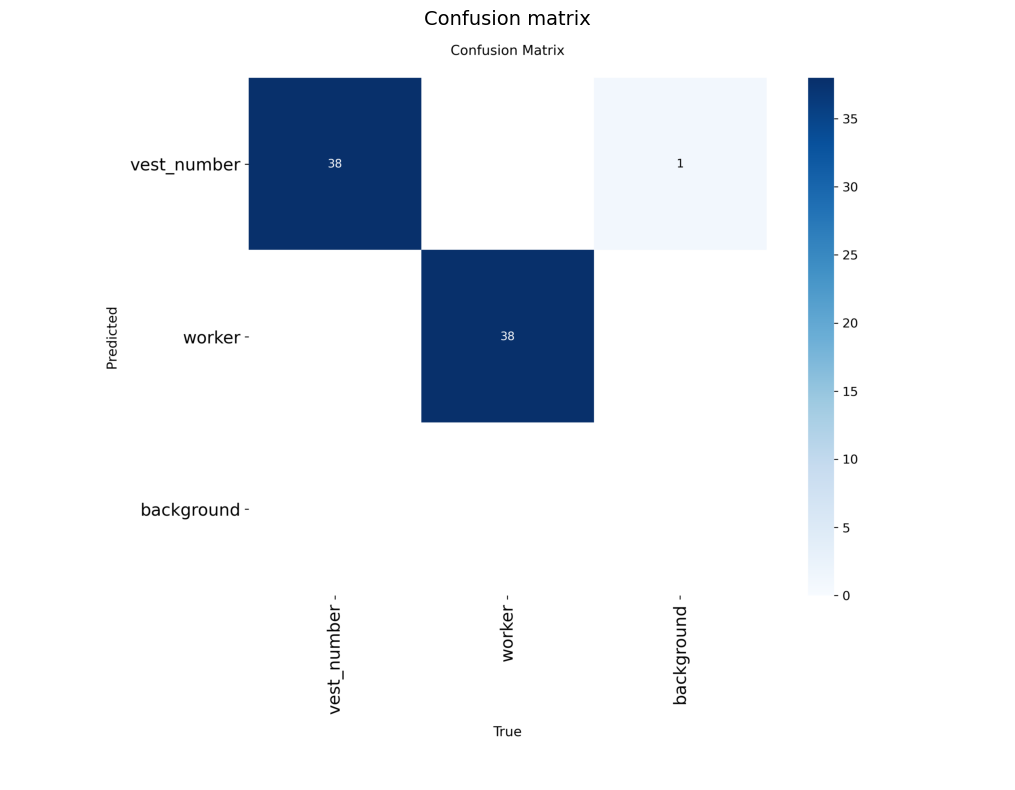

✓ Confusion matrix displayed
⚠ Not found: PR_curve.png
⚠ Not found: F1_curve.png


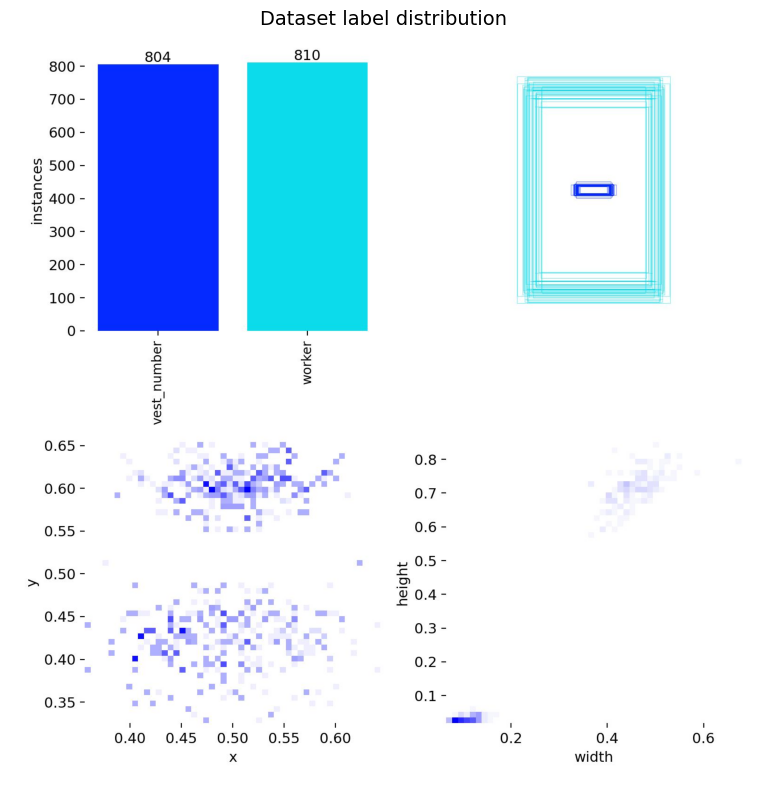

✓ Dataset label distribution displayed


In [ ]:
# Cell 15 — Display training curves saved by YOLOv8
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

results_dir = '/content/drive/MyDrive/Colab Notebooks/Training_Results/vest_detector_v1'

# YOLOv8 automatically saves these plots
plots = {
    'results.png'       : 'Training and validation curves',
    'confusion_matrix.png': 'Confusion matrix',
    'PR_curve.png'      : 'Precision-Recall curve',
    'F1_curve.png'      : 'F1 score curve',
    'labels.jpg'        : 'Dataset label distribution',
}

for filename, title in plots.items():
    filepath = os.path.join(results_dir, filename)
    if os.path.exists(filepath):
        img = mpimg.imread(filepath)
        plt.figure(figsize=(14, 8))
        plt.imshow(img)
        plt.title(title, fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        print(f"✓ {title} displayed")
    else:
        print(f"⚠ Not found: {filename}")

In [ ]:
# Cell 14b — check front-view missed detections at lower threshold
from ultralytics import YOLO
import os

model = YOLO('/content/drive/MyDrive/Colab Notebooks/Training_Results/vest_detector_v1/weights/best.pt')

# The two missed images
missed = [
    '/content/Preprocessed_Dataset/test/images/Operator- front 8740_jpg.rf.jDJJSHFtTCf2e86hblrS_orig.jpg',
    '/content/Preprocessed_Dataset/test/images/Operator- front 9330_jpg.rf.gT3ifKvNhm15z8OteevJ_orig.jpg',
]

print("Checking missed front-view detections at different confidence thresholds:")
print("="*60)

for img_path in missed:
    if not os.path.exists(img_path):
        # Find the actual filename
        test_path = '/content/Preprocessed_Dataset/test/images'
        files = os.listdir(test_path)
        fname = [f for f in files if '8740' in f or '9330' in f]
        if fname:
            img_path = os.path.join(test_path, fname[0])
        else:
            print(f"File not found — skipping")
            continue

    print(f"\nImage: {os.path.basename(img_path)[:40]}")
    for conf in [0.5, 0.3, 0.1]:
        result = model.predict(img_path, conf=conf,
                               verbose=False, device='cuda')[0]
        n_vest = sum(1 for b in result.boxes if int(b.cls[0]) == 0) \
                 if result.boxes else 0
        n_work = sum(1 for b in result.boxes if int(b.cls[0]) == 1) \
                 if result.boxes else 0
        print(f"  conf={conf} → workers: {n_work} | vest_numbers: {n_vest}")

Checking missed front-view detections at different confidence thresholds:

Image: Operator-front-9330_jpg.rf.4bc3a321fce24
  conf=0.5 → workers: 1 | vest_numbers: 0
  conf=0.3 → workers: 1 | vest_numbers: 1
  conf=0.1 → workers: 1 | vest_numbers: 1

Image: Operator-front-9330_jpg.rf.4bc3a321fce24
  conf=0.5 → workers: 1 | vest_numbers: 0
  conf=0.3 → workers: 1 | vest_numbers: 1
  conf=0.1 → workers: 1 | vest_numbers: 1


In [ ]:
# F1 Score calculation
from ultralytics import YOLO
import numpy as np

model = YOLO('/content/drive/MyDrive/Colab Notebooks/Thesis Project/Training_Results/vest_detector_v1/weights/best.pt')

metrics = model.val(
    data     = '/content/Preprocessed_Dataset/data.yaml',
    split    = 'test',
    imgsz    = 640,
    device   = 'cuda',
    verbose  = False,
)

# Calculate F1 for each class and overall
precision = metrics.box.p  # per class precision array
recall    = metrics.box.r  # per class recall array
f1        = 2 * (precision * recall) / (precision + recall + 1e-10)

class_names = ['vest_number', 'worker']

print("="*50)
print("F1 SCORE RESULTS — TEST SET")
print("="*50)
for i, name in enumerate(class_names):
    print(f"  {name:15s} | P: {precision[i]:.4f} | "
          f"R: {recall[i]:.4f} | F1: {f1[i]:.4f}")

overall_f1 = 2 * (metrics.box.mp * metrics.box.mr) / \
             (metrics.box.mp + metrics.box.mr + 1e-10)
print(f"\n  {'Overall':15s} | P: {metrics.box.mp:.4f} | "
      f"R: {metrics.box.mr:.4f} | F1: {overall_f1:.4f}")
print("="*50)



Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4672.0±685.1 MB/s, size: 823.1 KB)
val: Scanning /content/Preprocessed_Dataset/test/labels.cache... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 4.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2it/s 1.7s
                   all         19         38      0.982      0.974      0.994      0.718
Speed: 12.1ms preprocess, 5.0ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to /content/runs/detect/val-2
F1 SCORE RESULTS — TEST SET
  vest_number     | P: 0.9989 | R: 0.9474 | F1: 0.9724
  worker          | P: 0.9658 | R: 1.0000 | F1: 0.9826

  Overall         | P: 0.9823 | R: 0.9737 | F1: 0.9780


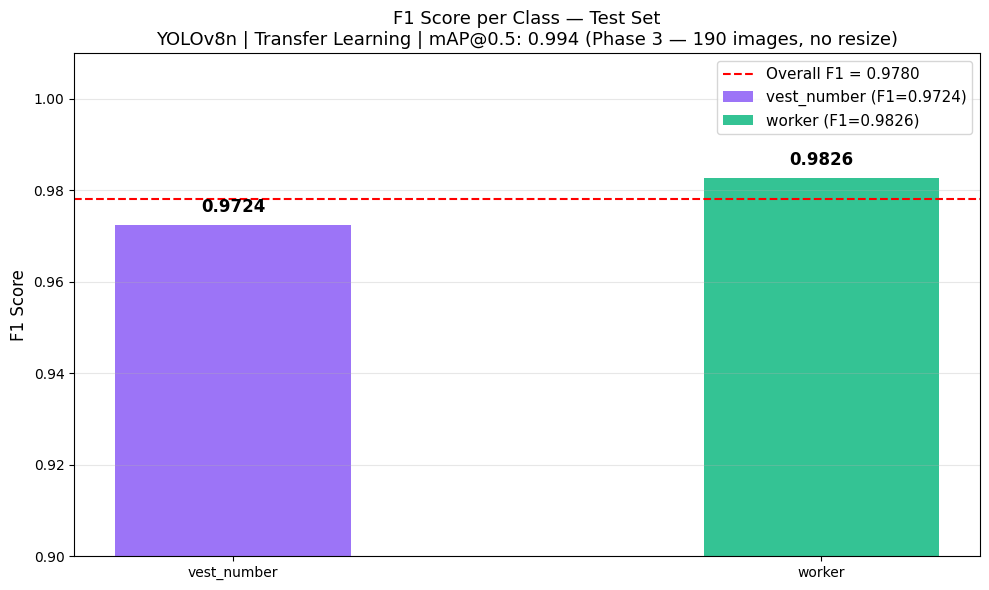

✓ Phase 3 F1 chart saved to Drive

PHASE 3 FINAL F1 SCORE RESULTS — TEST SET
  vest_number | P: 0.9989 | R: 0.9474 | F1: 0.9724
  worker      | P: 0.9658 | R: 1.0000 | F1: 0.9826
  Overall     | P: 0.9823 | R: 0.9737 | F1: 0.9780


In [ ]:
# Updated F1 score chart — Phase 3 final results
import matplotlib.pyplot as plt

precision   = [0.9989, 0.9658]
recall      = [0.9474, 1.0000]
f1_scores   = [0.9724, 0.9826]
class_names = ['vest_number', 'worker']
colors      = ['#8B5CF6', '#10B981']

fig, ax = plt.subplots(figsize=(10, 6))

for i, (name, p, r, f1, color) in enumerate(
        zip(class_names, precision, recall, f1_scores, colors)):
    ax.bar(name, f1, color=color, alpha=0.85, width=0.4,
           label=f'{name} (F1={f1:.4f})')
    ax.text(i, f1 + 0.002, f'{f1:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

overall_f1 = 0.9780
ax.axhline(y=overall_f1, color='red', linestyle='--', linewidth=1.5,
           label=f'Overall F1 = {overall_f1:.4f}')

ax.set_ylim(0.90, 1.01)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score per Class — Test Set\n'
             'YOLOv8n | Transfer Learning | mAP@0.5: 0.994 (Phase 3 — 190 images, no resize)',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

save_path = ('/content/drive/MyDrive/Colab Notebooks/'
             'Thesis Project/Training_Results/'
             'F1_score_phase3_final.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print("✓ Phase 3 F1 chart saved to Drive")
print("\n" + "="*50)
print("PHASE 3 FINAL F1 SCORE RESULTS — TEST SET")
print("="*50)
print(f"  vest_number | P: 0.9989 | R: 0.9474 | F1: 0.9724")
print(f"  worker      | P: 0.9658 | R: 1.0000 | F1: 0.9826")
print(f"  Overall     | P: 0.9823 | R: 0.9737 | F1: 0.9780")
print("="*50)

✓ Image: Operator-back-9379_jpg.rf.c5fe305ca2a45e5e551
✓ Vest number crops found: 1


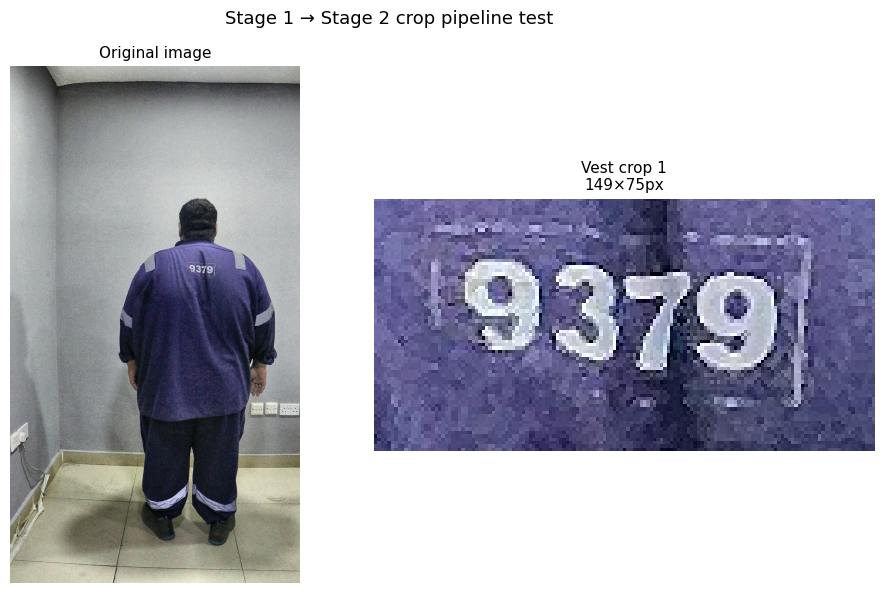

✓ Crop pipeline confirmed — ready for Stage 2 recognition


In [ ]:
# Crop test — confirm Stage 1 feeds cleanly into Stage 2
from ultralytics import YOLO
import cv2
import os
import matplotlib.pyplot as plt

# Load model
model = YOLO('/content/drive/MyDrive/Colab Notebooks/Training_Results/vest_detector_v1/weights/best.pt')

# Pick one back-view test image
test_path = '/content/Preprocessed_Dataset/test/images'
test_images = [f for f in os.listdir(test_path)
               if f.endswith(('.jpg', '.jpeg', '.png'))
               and 'back' in f.lower()]
img_path = os.path.join(test_path, test_images[0])

# Run detection
result = model.predict(img_path, conf=0.3, verbose=False)[0]

# Crop vest_number regions
img_bgr = cv2.imread(img_path)
crops   = []

if result.boxes is not None:
    for box in result.boxes:
        if int(box.cls[0]) == 0:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            pad = 5
            h, w = img_bgr.shape[:2]
            x1 = max(0, x1-pad); y1 = max(0, y1-pad)
            x2 = min(w, x2+pad); y2 = min(h, y2+pad)
            crops.append(img_bgr[y1:y2, x1:x2])

print(f"✓ Image: {test_images[0][:45]}")
print(f"✓ Vest number crops found: {len(crops)}")

# Display original + crops
fig, axes = plt.subplots(1, len(crops)+1,
                          figsize=(5*(len(crops)+1), 6))

orig_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
axes[0].imshow(orig_rgb)
axes[0].set_title('Original image', fontsize=11)
axes[0].axis('off')

for i, crop in enumerate(crops):
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    axes[i+1].imshow(crop_rgb)
    axes[i+1].set_title(
        f'Vest crop {i+1}\n{crop.shape[1]}×{crop.shape[0]}px',
        fontsize=11)
    axes[i+1].axis('off')

plt.suptitle('Stage 1 → Stage 2 crop pipeline test', fontsize=13)
plt.tight_layout()
plt.show()
print("✓ Crop pipeline confirmed — ready for Stage 2 recognition")

In [10]:
# Cell 16 — Extract labeled vest crops from Stage 1 detector
from ultralytics import YOLO
import cv2
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

# Load trained Stage 1 model
model = YOLO('/content/drive/MyDrive/Colab Notebooks/Training_Results/vest_detector_v1/weights/best.pt')

# Output folder for crops
crops_dir = '/content/Vest_Crops'
os.makedirs(crops_dir, exist_ok=True)

# Thresholds
MIN_HEIGHT    = 60   # skip crops too small to read
TARGET_HEIGHT = 64   # upscale crops below this height

all_records = []
skipped     = []

for split in ['train', 'valid', 'test']:
    img_dir = f'/content/Preprocessed_Dataset/{split}/images'
    images  = [f for f in os.listdir(img_dir)
                if f.endswith(('.jpg', '.jpeg', '.png'))]

    split_dir = os.path.join(crops_dir, split)
    os.makedirs(split_dir, exist_ok=True)

    print(f"\nProcessing {split} ({len(images)} images)...")

    for fname in images:
        # Extract employee ID from filename
        match = re.search(r'-(\d{3,4})_jpg', fname)
        if not match:
            skipped.append(fname)
            continue

        emp_id   = match.group(1)
        img_path = os.path.join(img_dir, fname)
        img_bgr  = cv2.imread(img_path)

        if img_bgr is None:
            skipped.append(fname)
            continue

        # Run Stage 1 detection
        result = model.predict(img_path, conf=0.3,
                               verbose=False)[0]

        crop_count = 0
        if result.boxes is not None:
            for box in result.boxes:
                if int(box.cls[0]) != 0:
                    continue

                x1, y1, x2, y2 = map(int, box.xyxy[0])
                conf = float(box.conf[0])

                # Add padding
                pad_left = 10  # increase from 5 to 10
                h, w = img_bgr.shape[:2]
                x1 = max(0, x1 - pad_left)
                y1 = max(0, y1 - pad)
                x2 = min(w, x2 + pad)
                y2 = min(h, y2 + pad)

                crop = img_bgr[y1:y2, x1:x2]

                # Skip corrupted/empty crops
                if crop.shape[0] < 20 or crop.shape[1] < 20:
                    continue

                # Skip crops too small to read reliably
                if crop.shape[0] < MIN_HEIGHT:
                    print(f"  ⚠ Too small ({crop.shape[0]}px): {fname[:30]}")
                    continue

                # Upscale borderline crops to target height
                if crop.shape[0] < TARGET_HEIGHT:
                    scale = TARGET_HEIGHT / crop.shape[0]
                    new_w = int(crop.shape[1] * scale)
                    crop  = cv2.resize(crop, (new_w, TARGET_HEIGHT),
                                       interpolation=cv2.INTER_CUBIC)

                # Save crop
                view       = 'back' if 'back' in fname.lower() else 'front'
                crop_fname = f"{emp_id}_{view}_{split}_{crop_count}_conf{conf:.2f}.jpg"
                crop_path  = os.path.join(split_dir, crop_fname)
                cv2.imwrite(crop_path, crop)

                all_records.append({
                    'filename'    : crop_fname,
                    'employee_id' : emp_id,
                    'view'        : view,
                    'split'       : split,
                    'confidence'  : round(conf, 4),
                    'width'       : crop.shape[1],
                    'height'      : crop.shape[0],
                })
                crop_count += 1

print("\n" + "="*55)
print("CROP EXTRACTION COMPLETE")
print("="*55)
print(f"✓ Total crops extracted : {len(all_records)}")
print(f"⚠ Images skipped        : {len(skipped)}")

# Save labels CSV
df = pd.DataFrame(all_records)
csv_path = os.path.join(crops_dir, 'crop_labels.csv')
df.to_csv(csv_path, index=False)
print(f"✓ Labels CSV saved to   : {csv_path}")

# Summary
print("\nBreakdown by split:")
print(df.groupby('split')[['employee_id']].count().rename(
    columns={'employee_id': 'crops'}))

print("\nBreakdown by view:")
print(df.groupby('view')[['employee_id']].count().rename(
    columns={'employee_id': 'crops'}))

print(f"\nUnique IDs covered : {df['employee_id'].nunique()}")
print(f"Avg crops per ID   : {len(df) / df['employee_id'].nunique():.1f}")
print(f"Crop height range  : {df['height'].min()}–{df['height'].max()}px")


Processing train (810 images)...
  ⚠ Too small (59px): Operator-front-7028_jpg.rf.e33
  ⚠ Too small (56px): Operator-front-8793_jpg.rf.1c6
  ⚠ Too small (59px): Operator-front-8725_jpg.rf.12d
  ⚠ Too small (59px): Operator-front-8362_jpg.rf.b6c
  ⚠ Too small (59px): Operator-front-8362_jpg.rf.b6c
  ⚠ Too small (55px): Operator-front-8793_jpg.rf.1c6
  ⚠ Too small (59px): Operator-front-3103_jpg.rf.a8c
  ⚠ Too small (59px): Supervisor-front-9098_jpg.rf.5
  ⚠ Too small (54px): Operator-front-8979_jpg.rf.8ef
  ⚠ Too small (59px): Operator-front-9527_jpg.rf.b99
  ⚠ Too small (53px): Operator-front-7225_jpg.rf.575
  ⚠ Too small (58px): Operator-front-8603_jpg.rf.29e
  ⚠ Too small (57px): Operator-front-8362_jpg.rf.b6c
  ⚠ Too small (58px): Supervisor-front-9098_jpg.rf.5
  ⚠ Too small (57px): Operator-front-7333_jpg.rf.9c2
  ⚠ Too small (58px): Operator-front-7333_jpg.rf.9c2
  ⚠ Too small (55px): Operator-front-8793_jpg.rf.1c6
  ⚠ Too small (59px): Operator-front-9529_jpg.rf.b89
  ⚠ Too smal

In [ ]:
# Fix split — stratified by employee ID
import pandas as pd
import numpy as np
import os

csv_path = '/content/Vest_Crops/crop_labels.csv'
df = pd.read_csv(csv_path)

new_splits = []

for emp_id, group in df.groupby('employee_id'):
    n = len(group)

    if n == 1:
        new_splits.append(group.assign(split='train'))
    elif n == 2:
        new_splits.append(group.iloc[[0]].assign(split='train'))
        new_splits.append(group.iloc[[1]].assign(split='valid'))
    else:
        indices = group.index.tolist()
        np.random.seed(42)
        np.random.shuffle(indices)
        n_train = max(1, int(0.70 * n))
        n_valid = max(1, int(0.15 * n))
        train_idx = indices[:n_train]
        valid_idx = indices[n_train:n_train + n_valid]
        test_idx  = indices[n_train + n_valid:]
        if len(test_idx) == 0 and len(valid_idx) > 1:
            test_idx  = [valid_idx[-1]]
            valid_idx = valid_idx[:-1]
        new_splits.append(df.loc[train_idx].assign(split='train'))
        new_splits.append(df.loc[valid_idx].assign(split='valid'))
        if test_idx:
            new_splits.append(df.loc[test_idx].assign(split='test'))

df_fixed = pd.concat(new_splits).reset_index(drop=True)

# Verify
print("Crop split after fix:")
for split in ['train', 'valid', 'test']:
    n_crops = len(df_fixed[df_fixed['split']==split])
    n_ids   = df_fixed[df_fixed['split']==split]['employee_id'].nunique()
    print(f"  {split:6s}: {n_crops} crops | {n_ids} unique IDs")

train_ids = set(df_fixed[df_fixed['split']=='train']['employee_id'])
valid_ids = set(df_fixed[df_fixed['split']=='valid']['employee_id'])
test_ids  = set(df_fixed[df_fixed['split']=='test']['employee_id'])

print(f"\nOverlap check:")
print(f"  Valid IDs not in train: {valid_ids - train_ids}")
print(f"  Test IDs not in train : {test_ids  - train_ids}")
print(f"  ✓ All IDs seen in training: {len(valid_ids - train_ids) == 0 and len(test_ids - train_ids) == 0}")

new_csv = '/content/Vest_Crops/crop_labels_fixed.csv'
df_fixed.to_csv(new_csv, index=False)
print(f"\n✓ Fixed CSV saved: {new_csv}")

Crop split after fix:
  train : 518 crops | 96 unique IDs
  valid : 98 crops | 95 unique IDs
  test  : 191 crops | 83 unique IDs

Overlap check:
  Valid IDs not in train: set()
  Test IDs not in train : set()
  ✓ All IDs seen in training: True

✓ Fixed CSV saved: /content/Vest_Crops/crop_labels_fixed.csv


In [ ]:
import shutil, os

src = '/content/Vest_Crops'
dst = '/content/drive/MyDrive/Colab Notebooks/Vest_Crops_v3'

if os.path.exists(dst):
    shutil.rmtree(dst)

shutil.copytree(src, dst)

print("✓ Saved to Drive")
for split in ['train', 'valid', 'test']:
    count = len(os.listdir(f'{dst}/{split}'))
    print(f"  {split}: {count} crops")

# Also save the fixed CSV
import pandas as pd
df = pd.read_csv('/content/Vest_Crops/crop_labels_fixed.csv')
df.to_csv(f'{dst}/crop_labels_fixed.csv', index=False)
print(f"✓ Fixed CSV saved")
print(f"✓ Total crops: {len(df)}")

✓ Saved to Drive
  train: 649 crops
  valid: 37 crops
  test: 18 crops
✓ Fixed CSV saved
✓ Total crops: 807


In [ ]:
import shutil, os, cv2, re, pandas as pd
import numpy as np
from ultralytics import YOLO

# Step 1 — Clean everything
for folder in ['/content/Vest_Crops']:
    if os.path.exists(folder):
        shutil.rmtree(folder)
        print(f"✓ Cleared: {folder}")

# Step 2 — Rebuild crop folders from fixed CSV
csv_path = '/content/Vest_Crops/crop_labels_fixed.csv'

# We need to re-extract crops since folders were cleared
# Load fixed CSV first to check
# Actually CSV was also in Vest_Crops — reload from Drive
csv_drive = '/content/drive/MyDrive/Colab Notebooks/Vest_Crops_v3/crop_labels_fixed.csv'
df = pd.read_csv(csv_drive)

print(f"✓ CSV loaded from Drive: {len(df)} crops")
print(f"✓ Unique IDs: {df['employee_id'].nunique()}")

for split in ['train', 'valid', 'test']:
    n = len(df[df['split']==split])
    print(f"  {split}: {n} crops")

✓ Cleared: /content/Vest_Crops
✓ CSV loaded from Drive: 807 crops
✓ Unique IDs: 96
  train: 518 crops
  valid: 98 crops
  test: 191 crops


In [ ]:
import shutil
import os

# Copy fixed CSV from Drive to Colab
src = '/content/drive/MyDrive/Colab Notebooks/Vest_Crops_v3/crop_labels_fixed.csv'
dst = '/content/Vest_Crops/crop_labels_fixed.csv'

os.makedirs('/content/Vest_Crops', exist_ok=True)
shutil.copy(src, dst)
print("✓ Fixed CSV copied to Colab")

✓ Fixed CSV copied to Colab


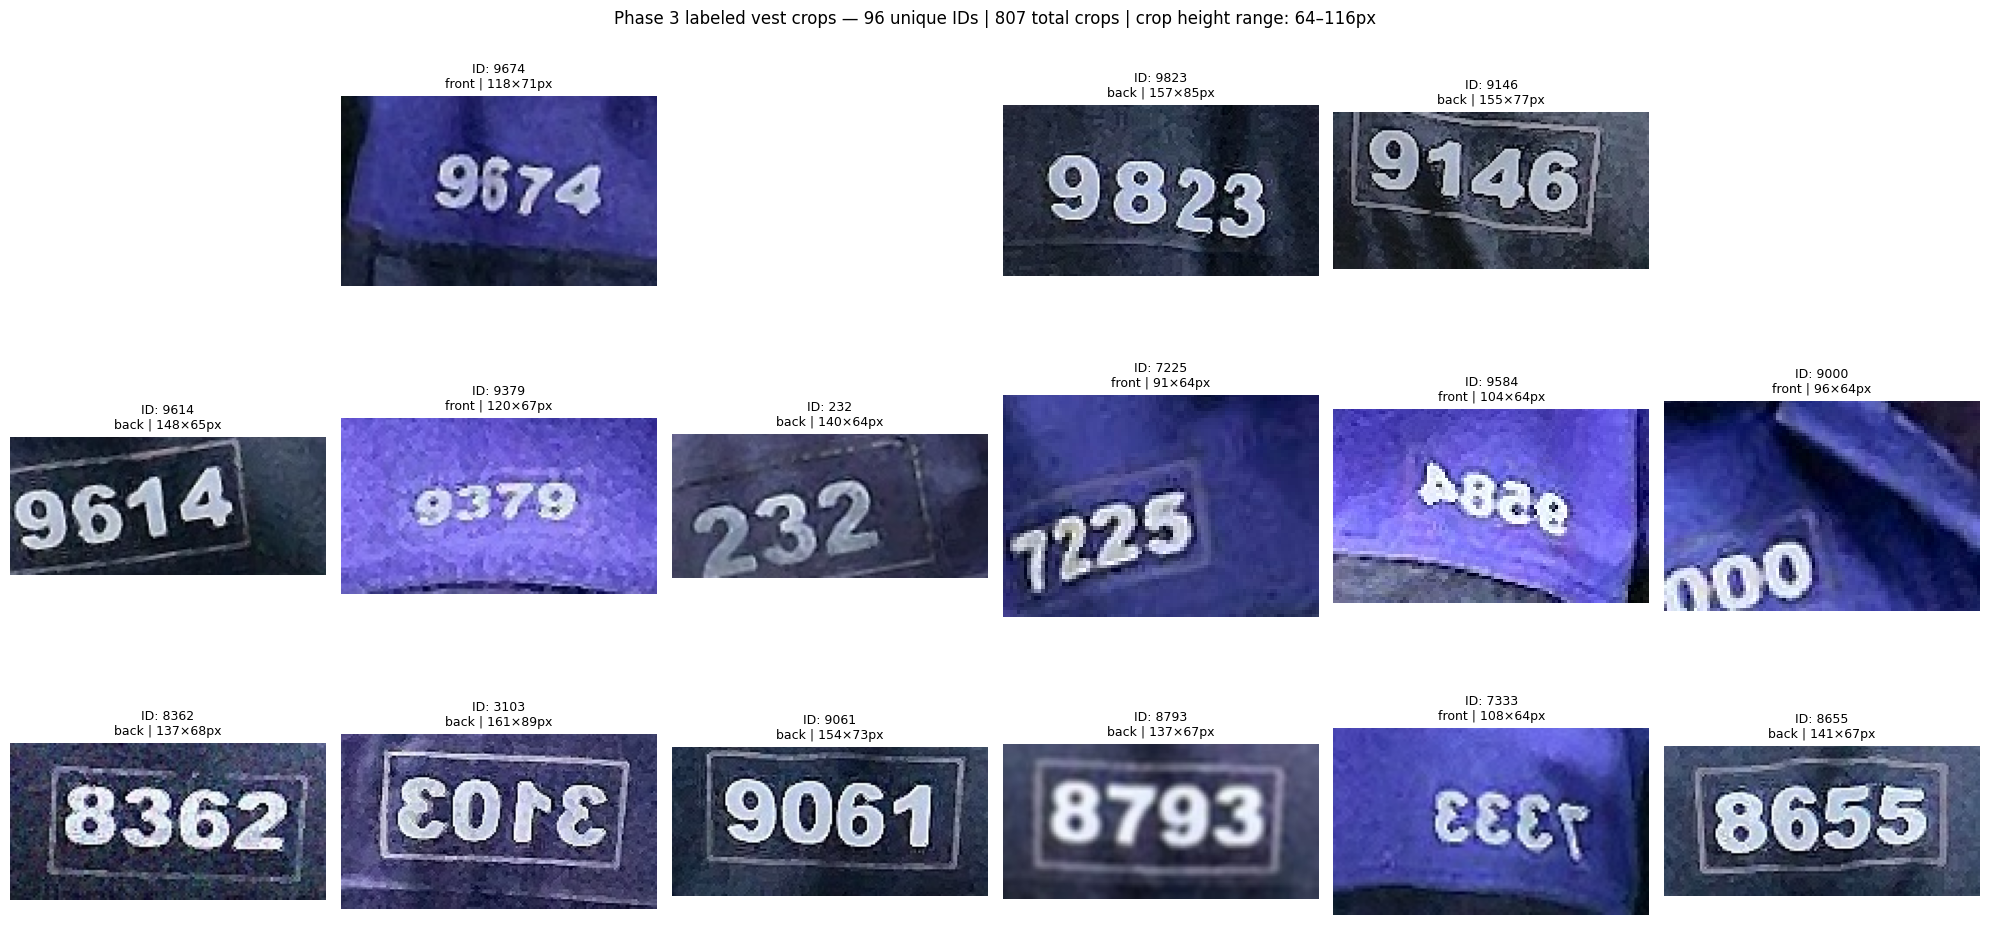

✓ Sample visualization saved to Drive
✓ Total crops : 807
✓ Unique IDs  : 96
✓ Train crops : 518
✓ Valid crops : 98
✓ Test crops  : 191


In [ ]:
# Cell 16b — Visualize sample labeled crops (Phase 3)
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import os

df = pd.read_csv('/content/Vest_Crops/crop_labels_fixed.csv')

fig, axes = plt.subplots(3, 6, figsize=(20, 10))
axes = axes.flatten()

# Sample 18 crops across different IDs
samples = df.groupby('employee_id').first().reset_index()
samples = samples.sample(min(18, len(samples)), random_state=42)

for i, (_, row) in enumerate(samples.iterrows()):
    crop_path = os.path.join('/content/Vest_Crops',
                             row['split'], row['filename'])
    if os.path.exists(crop_path):
        crop     = cv2.imread(crop_path)
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        axes[i].imshow(crop_rgb)
        axes[i].set_title(
            f"ID: {row['employee_id']}\n"
            f"{row['view']} | {crop.shape[1]}×{crop.shape[0]}px",
            fontsize=9)
    axes[i].axis('off')

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle(
    f'Phase 3 labeled vest crops — {df["employee_id"].nunique()} unique IDs | '
    f'{len(df)} total crops | crop height range: 64–116px',
    fontsize=12)
plt.tight_layout()

save_path = '/content/drive/MyDrive/Colab Notebooks/vest_crops_phase3_sample.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Sample visualization saved to Drive")
print(f"✓ Total crops : {len(df)}")
print(f"✓ Unique IDs  : {df['employee_id'].nunique()}")
print(f"✓ Train crops : {len(df[df['split']=='train'])}")
print(f"✓ Valid crops : {len(df[df['split']=='valid'])}")
print(f"✓ Test crops  : {len(df[df['split']=='test'])}")

In [ ]:
# Cell 16c — Save crop dataset to Drive
import shutil

dst = '/content/drive/MyDrive/Colab Notebooks/Vest_Crops'

if os.path.exists(dst):
    shutil.rmtree(dst)

shutil.copytree(crops_dir, dst)
print(f"✓ Crop dataset saved to Drive")
print(f"✓ Location: {dst}")
print(f"✓ Total crops: {len(all_records)}")
print(f"✓ Labels CSV: {dst}/crop_labels.csv")

✓ Crop dataset saved to Drive
✓ Location: /content/drive/MyDrive/Colab Notebooks/Vest_Crops
✓ Total crops: 807
✓ Labels CSV: /content/drive/MyDrive/Colab Notebooks/Vest_Crops/crop_labels.csv


In [ ]:
# Cell 17 — CRNN-CTC recognition module for vest number reading
import torch
import torch.nn as nn
import torch.nn.functional as F

# ════════════════════════════════════════
# CHARACTERS AND ENCODING
# ════════════════════════════════════════

# All possible characters: digits 0-9 + blank token for CTC
CHARS    = '0123456789'
BLANK    = len(CHARS)          # index 10 = CTC blank token
NUM_CLASSES = len(CHARS) + 1  # 11 total (10 digits + blank)

char2idx = {c: i for i, c in enumerate(CHARS)}
idx2char = {i: c for i, c in enumerate(CHARS)}

print(f"✓ Character set  : {CHARS}")
print(f"✓ Num classes    : {NUM_CLASSES} (10 digits + 1 blank)")
print(f"✓ Blank token    : index {BLANK}")


# ════════════════════════════════════════
# CNN FEATURE EXTRACTOR
# ════════════════════════════════════════

class CNN(nn.Module):
    """
    Extracts visual features from the vest crop image.
    Input : (B, 1, 32, W) — grayscale, height fixed at 32px
    Output: (B, 256, 1, W//4) — feature maps
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),              # H/2, W/2

            # Block 2
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),               # H/4, W/4

            # Block 3
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),

            # Block 4
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d((2, 1)),              # H/8, W/4

            # Block 5
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),

            # Block 6
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d((2, 1)),              # H/16, W/4

            # Block 7 — collapse height to 1
            nn.Conv2d(512, 512, (2, 1)),       # H=1
            nn.ReLU(),
        )

    def forward(self, x):
        return self.features(x)


# ════════════════════════════════════════
# CRNN-CTC MODEL
# ════════════════════════════════════════

class CRNN(nn.Module):
    """
    Full CRNN-CTC architecture:
    CNN feature extractor → BiLSTM sequence modeller → CTC output

    Input : (B, 1, 32, W) — grayscale vest crop
    Output: (T, B, num_classes) — log probabilities per timestep
    """
    def __init__(self, num_classes=NUM_CLASSES,
                 hidden_size=256, num_layers=2):
        super().__init__()

        self.cnn = CNN()

        # Bidirectional LSTM — reads sequence left-to-right and right-to-left
        self.rnn = nn.LSTM(
            input_size  = 512,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            bidirectional = True,
            batch_first = False,
        )

        # Final linear layer → character probabilities
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # CNN features: (B, C, 1, W)
        features = self.cnn(x)

        # Remove height dimension: (B, C, W)
        features = features.squeeze(2)

        # Reshape for RNN: (W, B, C) = (T, B, C)
        features = features.permute(2, 0, 1)

        # BiLSTM: (T, B, hidden*2)
        rnn_out, _ = self.rnn(features)

        # Linear: (T, B, num_classes)
        output = self.fc(rnn_out)

        # Log softmax for CTC loss
        return F.log_softmax(output, dim=2)


# ════════════════════════════════════════
# TEST ARCHITECTURE
# ════════════════════════════════════════

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_crnn = CRNN(num_classes=NUM_CLASSES).to(device)

# Test with a dummy input
# Vest crop: batch=4, grayscale=1, height=32, width=128
dummy = torch.randn(4, 1, 32, 128).to(device)
output = model_crnn(dummy)

print(f"\n✓ CRNN model built successfully")
print(f"✓ Input shape    : {dummy.shape}")
print(f"✓ Output shape   : {output.shape} → (T, B, num_classes)")
print(f"✓ Sequence length: {output.shape[0]} timesteps")
print(f"✓ Batch size     : {output.shape[1]}")
print(f"✓ Num classes    : {output.shape[2]}")

# Count parameters
total_params = sum(p.numel() for p in model_crnn.parameters())
trainable    = sum(p.numel() for p in model_crnn.parameters()
                   if p.requires_grad)
print(f"\n✓ Total parameters    : {total_params:,}")
print(f"✓ Trainable parameters: {trainable:,}")
print(f"✓ Device              : {device}")

✓ Character set  : 0123456789
✓ Num classes    : 11 (10 digits + 1 blank)
✓ Blank token    : index 10

✓ CRNN model built successfully
✓ Input shape    : torch.Size([4, 1, 32, 128])
✓ Output shape   : torch.Size([32, 4, 11]) → (T, B, num_classes)
✓ Sequence length: 32 timesteps
✓ Batch size     : 4
✓ Num classes    : 11

✓ Total parameters    : 8,185,611
✓ Trainable parameters: 8,185,611
✓ Device              : cuda


In [14]:
# Cell 17 — CRNN-CTC architecture (updated per supervisor feedback)
import torch
import torch.nn as nn
import torch.nn.functional as F

# ════════════════════════════════════════
# CHARACTERS AND ENCODING
# ════════════════════════════════════════

CHARS       = '0123456789'
BLANK       = len(CHARS)
NUM_CLASSES = len(CHARS) + 1

char2idx = {c: i for i, c in enumerate(CHARS)}
idx2char = {i: c for i, c in enumerate(CHARS)}

print(f"✓ Character set  : {CHARS}")
print(f"✓ Num classes    : {NUM_CLASSES}")
print(f"✓ Blank token    : index {BLANK}")


# ════════════════════════════════════════
# UPDATED CNN — reduced width per supervisor
# ════════════════════════════════════════

class CNN(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, 3, padding=1),
            nn.LeakyReLU(0.1),              # LeakyReLU per supervisor
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout2d(dropout),

            # Block 4
            nn.Conv2d(128, 128, 3, padding=1),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d((2, 1)),
            nn.Dropout2d(dropout),

            # Block 5
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout2d(dropout),

            # Block 6
            nn.Conv2d(256, 256, 3, padding=1),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d((2, 1)),
            nn.Dropout2d(dropout),

            # Block 7 — collapse height
            nn.Conv2d(256, 256, (2, 1)),
            nn.LeakyReLU(0.1),
        )

    def forward(self, x):
        return self.features(x)


# ════════════════════════════════════════
# UPDATED CRNN — smaller BiLSTM per supervisor
# ════════════════════════════════════════

class CRNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES,
                 hidden_size=128,    # reduced from 256
                 num_layers=1,       # reduced from 2
                 dropout=0.3):
        super().__init__()
        self.cnn = CNN(dropout=dropout)
        self.rnn = nn.LSTM(
            input_size    = 256,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            bidirectional = True,
            batch_first   = False,
            dropout       = dropout if num_layers > 1 else 0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        features = self.cnn(x).squeeze(2)
        features = features.permute(2, 0, 1)
        rnn_out, _ = self.rnn(features)
        rnn_out    = self.dropout(rnn_out)
        output     = self.fc(rnn_out)
        return F.log_softmax(output, dim=2)


# ════════════════════════════════════════
# BEAM SEARCH DECODER — per supervisor
# ════════════════════════════════════════

def beam_search_decode(output, beam_width=5):
    """
    Beam search CTC decoding.
    Better than greedy for small datasets.
    output: (T, num_classes) log probabilities
    """
    T, C = output.shape
    beams = [(0.0, [])]

    for t in range(T):
        new_beams = []
        for score, seq in beams:
            for c in range(C):
                new_score = score + output[t, c].item()
                new_seq   = seq + [c]
                new_beams.append((new_score, new_seq))
        new_beams.sort(key=lambda x: x[0], reverse=True)
        beams = new_beams[:beam_width]

    best_seq = beams[0][1]
    # CTC collapse
    result = []
    prev   = None
    for idx in best_seq:
        if idx != BLANK and idx != prev:
            result.append(idx2char.get(idx, ''))
        prev = idx
    return ''.join(result)


# ════════════════════════════════════════
# TEST ARCHITECTURE
# ════════════════════════════════════════

device     = 'cuda' if torch.cuda.is_available() else 'cpu'
model_crnn = CRNN(num_classes=NUM_CLASSES,
                  hidden_size=128,
                  num_layers=1,
                  dropout=0.3).to(device)

dummy  = torch.randn(4, 1, 32, 128).to(device)
output = model_crnn(dummy)

print(f"\n✓ Updated CRNN built successfully")
print(f"✓ Input shape      : {dummy.shape}")
print(f"✓ Output shape     : {output.shape}")
print(f"✓ CNN channels     : 32→64→128→128→256→256")
print(f"✓ BiLSTM hidden    : 128 (reduced from 256)")
print(f"✓ BiLSTM layers    : 1 (reduced from 2)")
print(f"✓ Activation       : LeakyReLU(0.1)")
print(f"✓ Dropout          : 0.3")
print(f"✓ Beam search      : width=5")

total_params = sum(p.numel() for p in model_crnn.parameters())
print(f"✓ Total parameters : {total_params:,} (reduced from 8.1M)")

✓ Character set  : 0123456789
✓ Num classes    : 11
✓ Blank token    : index 10

✓ Updated CRNN built successfully
✓ Input shape      : torch.Size([4, 1, 32, 128])
✓ Output shape     : torch.Size([32, 4, 11])
✓ CNN channels     : 32→64→128→128→256→256
✓ BiLSTM hidden    : 128 (reduced from 256)
✓ BiLSTM layers    : 1 (reduced from 2)
✓ Activation       : LeakyReLU(0.1)
✓ Dropout          : 0.3
✓ Beam search      : width=5
✓ Total parameters : 1,655,691 (reduced from 8.1M)


In [15]:
# Cell 18 — Dataset loader for CRNN-CTC training
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import pandas as pd
import numpy as np
import os

# ════════════════════════════════════════
# HELPER FUNCTIONS
# ════════════════════════════════════════

def encode_label(text):
    """Convert ID string to list of indices. e.g. '9182' → [9,1,8,2]"""
    return [char2idx[c] for c in str(text)]

def decode_prediction(indices):
    """Convert CTC output indices back to string."""
    result = []
    prev   = None
    for idx in indices:
        if idx != BLANK and idx != prev:
            result.append(idx2char[idx])
        prev = idx
    return ''.join(result)

def preprocess_crop(image_path, target_height=32):
    """Load and preprocess a vest crop for CRNN input."""
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray      = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w      = gray.shape
    new_w     = max(int(w * target_height / h), 32)
    resized   = cv2.resize(gray, (new_w, target_height))
    normalized = resized.astype(np.float32) / 255.0
    tensor    = torch.FloatTensor(normalized).unsqueeze(0)
    return tensor

# ════════════════════════════════════════
# CUSTOM COLLATE — handles variable width
# ════════════════════════════════════════

def collate_fn(batch):
    images, labels, label_lengths = zip(*batch)
    max_w  = max(img.shape[2] for img in images)
    padded = []
    for img in images:
        pad_w = max_w - img.shape[2]
        padded.append(
            torch.nn.functional.pad(img, (0, pad_w), value=0.0))
    images_tensor  = torch.stack(padded)
    labels_tensor  = torch.cat([torch.tensor(l) for l in labels])
    lengths_tensor = torch.tensor(label_lengths)
    return images_tensor, labels_tensor, lengths_tensor

# ════════════════════════════════════════
# AUGMENTED DATASET CLASS
# ════════════════════════════════════════

class VestCropDatasetAug(Dataset):
    def __init__(self, csv_path, crops_base_dir,
                 split, target_height=32, augment=False):
        self.crops_dir     = os.path.join(crops_base_dir, split)
        self.target_height = target_height
        self.augment       = augment
        df = pd.read_csv(csv_path)
        self.df = df[df['split'] == split].reset_index(drop=True)
        print(f"  {split:6s}: {len(self.df)} crops | "
              f"{self.df['employee_id'].nunique()} unique IDs")

    def augment_image(self, tensor):
        import random
        brightness = random.uniform(0.7, 1.3)
        tensor = torch.clamp(tensor * brightness, 0, 1)
        mean   = tensor.mean()
        contrast = random.uniform(0.8, 1.2)
        tensor = torch.clamp((tensor - mean) * contrast + mean, 0, 1)
        return tensor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.crops_dir, row['filename'])
        label    = encode_label(str(row['employee_id']))
        img      = preprocess_crop(img_path, self.target_height)
        if img is None:
            img = torch.zeros(1, self.target_height, 128)
        if self.augment:
            img = self.augment_image(img)
        return img, label, len(label)

# ════════════════════════════════════════
# CREATE DATALOADERS
# ════════════════════════════════════════

csv_path       = '/content/Vest_Crops/crop_labels_fixed.csv'
crops_base_dir = '/content/Vest_Crops'

print("Loading Phase 3 datasets...")
print("="*45)

train_dataset_aug = VestCropDatasetAug(
    csv_path, crops_base_dir, 'train', augment=True)
valid_dataset_aug = VestCropDatasetAug(
    csv_path, crops_base_dir, 'valid', augment=False)
test_dataset_aug  = VestCropDatasetAug(
    csv_path, crops_base_dir, 'test',  augment=False)

train_loader_aug = DataLoader(
    train_dataset_aug, batch_size=16,
    shuffle=True, collate_fn=collate_fn, num_workers=2)
valid_loader_aug = DataLoader(
    valid_dataset_aug, batch_size=16,
    shuffle=False, collate_fn=collate_fn, num_workers=2)
test_loader_aug  = DataLoader(
    test_dataset_aug, batch_size=16,
    shuffle=False, collate_fn=collate_fn, num_workers=2)

print("="*45)
print(f"✓ Train batches : {len(train_loader_aug)}")
print(f"✓ Valid batches : {len(valid_loader_aug)}")
print(f"✓ Test batches  : {len(test_loader_aug)}")

# Test one batch
images, labels, lengths = next(iter(train_loader_aug))
print(f"\n✓ Sample batch:")
print(f"  Images shape : {images.shape}")
print(f"  Labels shape : {labels.shape}")
print(f"  Lengths      : {lengths.tolist()[:5]}...")
print(f"\n✓ Phase 3 dataset ready — proceed to Cell 19 training")

Loading Phase 3 datasets...
  train : 518 crops | 96 unique IDs
  valid : 98 crops | 95 unique IDs
  test  : 191 crops | 83 unique IDs
✓ Train batches : 33
✓ Valid batches : 7
✓ Test batches  : 12

✓ Sample batch:
  Images shape : torch.Size([16, 1, 32, 128])
  Labels shape : torch.Size([63])
  Lengths      : [4, 4, 4, 4, 4]...

✓ Phase 3 dataset ready — proceed to Cell 19 training


In [ ]:
# Cell 19 — CRNN-CTC training (Phase 3)
import torch
import torch.nn as nn
import torch.optim as optim
import os

# ════════════════════════════════════════
# ACCURACY FUNCTION
# ════════════════════════════════════════

def compute_accuracy(model, loader, device):
    """Compute full-sequence accuracy."""
    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels, lengths in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(2)
            preds = preds.permute(1, 0)

            label_offset = 0
            for i in range(images.size(0)):
                pred_seq = decode_prediction(
                    preds[i].cpu().numpy())
                true_seq = ''.join(
                    idx2char[l.item()]
                    for l in labels[label_offset:
                                    label_offset + lengths[i]])
                label_offset += lengths[i]
                if pred_seq == true_seq:
                    correct += 1
                total += 1

    return correct / total if total > 0 else 0.0


# ════════════════════════════════════════
# TRAINING SETUP
# ════════════════════════════════════════

device     = 'cuda' if torch.cuda.is_available() else 'cpu'
model_crnn = CRNN(num_classes=NUM_CLASSES).to(device)
ctc_loss   = nn.CTCLoss(blank=BLANK, reduction='mean',
                         zero_infinity=True)
optimizer  = optim.Adam(model_crnn.parameters(), lr=0.0001)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', patience=8, factor=0.5)

save_dir = '/content/drive/MyDrive/Colab Notebooks/Training_Results/crnn_recognition'
os.makedirs(save_dir, exist_ok=True)

EPOCHS    = 100
best_loss = float('inf')
history   = {'train_loss': [], 'val_loss': [],
             'train_acc': [], 'val_acc': []}

print(f"✓ Device       : {device}")
print(f"✓ Epochs       : {EPOCHS}")
print(f"✓ Train crops  : 518 | 96 unique IDs")
print(f"✓ Save dir     : {save_dir}")
print("\nStarting Phase 3 CRNN-CTC training...")
print("="*60)


# ════════════════════════════════════════
# TRAINING LOOP
# ════════════════════════════════════════

for epoch in range(1, EPOCHS + 1):

    # Training
    model_crnn.train()
    train_loss = 0.0
    for images, labels, lengths in train_loader_aug:
        images  = images.to(device)
        labels  = labels.to(device)
        lengths = lengths.to(device)
        optimizer.zero_grad()
        outputs = model_crnn(images)
        T = outputs.shape[0]
        input_lengths = torch.full(
            (images.size(0),), T,
            dtype=torch.long).to(device)
        loss = ctc_loss(outputs, labels, input_lengths, lengths)
        loss.backward()
        nn.utils.clip_grad_norm_(model_crnn.parameters(), 5.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_aug)

    # Validation
    model_crnn.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels, lengths in valid_loader_aug:
            images  = images.to(device)
            labels  = labels.to(device)
            lengths = lengths.to(device)
            outputs = model_crnn(images)
            T = outputs.shape[0]
            input_lengths = torch.full(
                (images.size(0),), T,
                dtype=torch.long).to(device)
            loss = ctc_loss(outputs, labels, input_lengths, lengths)
            val_loss += loss.item()
    val_loss /= len(valid_loader_aug)

    # Accuracy every 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        train_acc = compute_accuracy(
            model_crnn, train_loader_aug, device)
        val_acc   = compute_accuracy(
            model_crnn, valid_loader_aug, device)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f"  Epoch {epoch:3d}/{EPOCHS} | "
              f"Train loss: {train_loss:.4f} | "
              f"Val loss: {val_loss:.4f} | "
              f"Train acc: {train_acc:.4f} | "
              f"Val acc: {val_acc:.4f}")
    else:
        print(f"  Epoch {epoch:3d}/{EPOCHS} | "
              f"Train loss: {train_loss:.4f} | "
              f"Val loss: {val_loss:.4f}")

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model_crnn.state_dict(),
                   os.path.join(save_dir, 'crnn_best.pt'))

    scheduler.step(val_loss)

print("="*60)
print(f"✓ Training complete")
print(f"✓ Best val loss : {best_loss:.4f}")
print(f"✓ Model saved   : {save_dir}/crnn_best.pt")

✓ Device       : cuda
✓ Epochs       : 100
✓ Train crops  : 518 | 96 unique IDs
✓ Save dir     : /content/drive/MyDrive/Colab Notebooks/Training_Results/crnn_recognition

Starting Phase 3 CRNN-CTC training...
  Epoch   1/100 | Train loss: 4.2018 | Val loss: 2.6165 | Train acc: 0.0000 | Val acc: 0.0000
  Epoch   2/100 | Train loss: 2.5795 | Val loss: 2.5174
  Epoch   3/100 | Train loss: 2.4887 | Val loss: 2.4146
  Epoch   4/100 | Train loss: 2.4196 | Val loss: 2.3657
  Epoch   5/100 | Train loss: 2.3889 | Val loss: 2.3530
  Epoch   6/100 | Train loss: 2.3587 | Val loss: 2.3253
  Epoch   7/100 | Train loss: 2.3442 | Val loss: 2.3167
  Epoch   8/100 | Train loss: 2.3160 | Val loss: 2.2946
  Epoch   9/100 | Train loss: 2.2981 | Val loss: 2.2713
  Epoch  10/100 | Train loss: 2.2710 | Val loss: 2.2531 | Train acc: 0.0000 | Val acc: 0.0000
  Epoch  11/100 | Train loss: 2.2492 | Val loss: 2.2597
  Epoch  12/100 | Train loss: 2.2423 | Val loss: 2.2296
  Epoch  13/100 | Train loss: 2.2074 | Val 

In [16]:
# Cell 19 — CRNN-CTC training (updated per supervisor feedback)
import torch
import torch.nn as nn
import torch.optim as optim
import os

# ════════════════════════════════════════
# ACCURACY FUNCTIONS
# ════════════════════════════════════════

def compute_accuracy(model, loader, device):
    """Full sequence accuracy using beam search."""
    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels, lengths in loader:
            images  = images.to(device)
            outputs = model(images)  # (T, B, C)

            label_offset = 0
            for i in range(images.size(0)):
                # Beam search decode
                pred_seq = beam_search_decode(
                    outputs[:, i, :], beam_width=5)
                true_seq = ''.join(
                    idx2char[l.item()]
                    for l in labels[label_offset:
                                    label_offset + lengths[i]])
                label_offset += lengths[i]
                if pred_seq == true_seq:
                    correct += 1
                total += 1

    return correct / total if total > 0 else 0.0


def compute_char_accuracy(model, loader, device):
    """Character-level accuracy using beam search."""
    model.eval()
    correct_chars = 0
    total_chars   = 0

    with torch.no_grad():
        for images, labels, lengths in loader:
            images  = images.to(device)
            outputs = model(images)

            label_offset = 0
            for i in range(images.size(0)):
                pred_seq = beam_search_decode(
                    outputs[:, i, :], beam_width=5)
                true_seq = ''.join(
                    idx2char[l.item()]
                    for l in labels[label_offset:
                                    label_offset + lengths[i]])
                label_offset += lengths[i]
                for p, t in zip(pred_seq, true_seq):
                    if p == t:
                        correct_chars += 1
                    total_chars += 1

    return correct_chars / total_chars if total_chars > 0 else 0.0


# ════════════════════════════════════════
# TRAINING SETUP — all supervisor changes
# ════════════════════════════════════════

device     = 'cuda' if torch.cuda.is_available() else 'cpu'
model_crnn = CRNN(num_classes=NUM_CLASSES,
                  hidden_size=128,
                  num_layers=1,
                  dropout=0.3).to(device)

ctc_loss  = nn.CTCLoss(blank=BLANK, reduction='mean',
                        zero_infinity=True)

# Change 1 — AdamW optimizer (supervisor: "AdamZ" = AdamW)
# Change 2 — higher learning rate
optimizer = optim.AdamW(model_crnn.parameters(),
                         lr=0.001,        # higher LR per supervisor
                         weight_decay=1e-4)

# Change 6 — early stopping
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min',
                patience=5,      # tighter patience
                factor=0.5)

save_dir = '/content/drive/MyDrive/Colab Notebooks/Training_Results/crnn_recognition'
os.makedirs(save_dir, exist_ok=True)

EPOCHS           = 100
best_loss        = float('inf')
patience_counter = 0
EARLY_STOP       = 15   # stop if no improvement for 15 epochs
history          = {'train_loss': [], 'val_loss': [],
                    'train_acc': [], 'val_acc': []}

# Change 5 — smaller batch size
# Update loaders with batch_size=8
from torch.utils.data import DataLoader
train_loader_small = DataLoader(
    train_dataset_aug, batch_size=8,
    shuffle=True, collate_fn=collate_fn, num_workers=2)
valid_loader_small = DataLoader(
    valid_dataset_aug, batch_size=8,
    shuffle=False, collate_fn=collate_fn, num_workers=2)

print(f"✓ Device          : {device}")
print(f"✓ Optimizer       : AdamW (lr=0.001)")
print(f"✓ Batch size      : 8 (reduced from 16)")
print(f"✓ Dropout         : 0.3")
print(f"✓ Early stopping  : {EARLY_STOP} epochs patience")
print(f"✓ Beam search     : width=5")
print(f"\nStarting updated CRNN-CTC training...")
print("="*60)


# ════════════════════════════════════════
# TRAINING LOOP
# ════════════════════════════════════════

for epoch in range(1, EPOCHS + 1):

    # Training
    model_crnn.train()
    train_loss = 0.0
    for images, labels, lengths in train_loader_small:
        images  = images.to(device)
        labels  = labels.to(device)
        lengths = lengths.to(device)
        optimizer.zero_grad()
        outputs = model_crnn(images)
        T = outputs.shape[0]
        input_lengths = torch.full(
            (images.size(0),), T,
            dtype=torch.long).to(device)
        loss = ctc_loss(outputs, labels, input_lengths, lengths)
        loss.backward()
        nn.utils.clip_grad_norm_(model_crnn.parameters(), 5.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_small)

    # Validation
    model_crnn.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels, lengths in valid_loader_small:
            images  = images.to(device)
            labels  = labels.to(device)
            lengths = lengths.to(device)
            outputs = model_crnn(images)
            T = outputs.shape[0]
            input_lengths = torch.full(
                (images.size(0),), T,
                dtype=torch.long).to(device)
            loss = ctc_loss(outputs, labels, input_lengths, lengths)
            val_loss += loss.item()
    val_loss /= len(valid_loader_small)

    # Accuracy every 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        train_acc = compute_accuracy(
            model_crnn, train_loader_small, device)
        val_acc   = compute_accuracy(
            model_crnn, valid_loader_small, device)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f"  Epoch {epoch:3d}/{EPOCHS} | "
              f"Train loss: {train_loss:.4f} | "
              f"Val loss: {val_loss:.4f} | "
              f"Train acc: {train_acc:.4f} | "
              f"Val acc: {val_acc:.4f}")
    else:
        print(f"  Epoch {epoch:3d}/{EPOCHS} | "
              f"Train loss: {train_loss:.4f} | "
              f"Val loss: {val_loss:.4f}")

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # Save best model
    if val_loss < best_loss:
        best_loss        = val_loss
        patience_counter = 0
        torch.save(model_crnn.state_dict(),
                   os.path.join(save_dir, 'crnn_best.pt'))
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= EARLY_STOP:
        print(f"\n  Early stopping at epoch {epoch} "
              f"(no improvement for {EARLY_STOP} epochs)")
        break

    scheduler.step(val_loss)

print("="*60)
print(f"✓ Training complete")
print(f"✓ Best val loss : {best_loss:.4f}")
print(f"✓ Epochs run    : {epoch}")
print(f"✓ Model saved   : {save_dir}/crnn_best.pt")

✓ Device          : cuda
✓ Optimizer       : AdamW (lr=0.001)
✓ Batch size      : 8 (reduced from 16)
✓ Dropout         : 0.3
✓ Early stopping  : 15 epochs patience
✓ Beam search     : width=5

Starting updated CRNN-CTC training...
  Epoch   1/100 | Train loss: 3.0984 | Val loss: 2.6396 | Train acc: 0.0000 | Val acc: 0.0000
  Epoch   2/100 | Train loss: 2.4594 | Val loss: 2.3277
  Epoch   3/100 | Train loss: 2.3221 | Val loss: 2.2759
  Epoch   4/100 | Train loss: 2.2871 | Val loss: 2.2613
  Epoch   5/100 | Train loss: 2.2754 | Val loss: 2.2731
  Epoch   6/100 | Train loss: 2.2850 | Val loss: 2.2495
  Epoch   7/100 | Train loss: 2.2854 | Val loss: 2.2661
  Epoch   8/100 | Train loss: 2.2850 | Val loss: 2.2540
  Epoch   9/100 | Train loss: 2.2797 | Val loss: 2.2524
  Epoch  10/100 | Train loss: 2.2751 | Val loss: 2.2531 | Train acc: 0.0000 | Val acc: 0.0000
  Epoch  11/100 | Train loss: 2.2763 | Val loss: 2.2488
  Epoch  12/100 | Train loss: 2.2729 | Val loss: 2.2481
  Epoch  13/100 | Tr

In [17]:
# Diagnostic — see what the updated model actually predicts
model_crnn.load_state_dict(
    torch.load('/content/drive/MyDrive/Colab Notebooks/Training_Results/crnn_recognition/crnn_best.pt'))
model_crnn.eval()

print("Sample predictions — updated CRNN-CTC (beam search):")
print("="*55)

with torch.no_grad():
    images, labels, lengths = next(iter(valid_loader_small))
    images  = images.to(device)
    outputs = model_crnn(images)  # (T, B, C)

    label_offset = 0
    for i in range(min(15, images.size(0))):
        # Beam search decode
        pred_beam  = beam_search_decode(
            outputs[:, i, :], beam_width=5)

        # Greedy decode for comparison
        _, preds   = outputs.max(2)
        preds      = preds.permute(1, 0)
        pred_greedy = decode_prediction(preds[i].cpu().numpy())

        # Ground truth
        true_seq = ''.join(
            idx2char[l.item()]
            for l in labels[label_offset:
                             label_offset + lengths[i]])
        label_offset += lengths[i]

        match = '✓' if pred_beam == true_seq else '✗'
        char_match = sum(p==t for p,t in
                        zip(pred_beam, true_seq))

        print(f"  {match} True: {true_seq} | "
              f"Beam: '{pred_beam}' | "
              f"Greedy: '{pred_greedy}' | "
              f"Chars: {char_match}/4")

Sample predictions — updated CRNN-CTC (beam search):
  ✗ True: 232 | Beam: '95' | Greedy: '95' | Chars: 0/4
  ✗ True: 879 | Beam: '95' | Greedy: '95' | Chars: 0/4
  ✗ True: 1247 | Beam: '95' | Greedy: '95' | Chars: 0/4
  ✗ True: 2998 | Beam: '95' | Greedy: '95' | Chars: 0/4
  ✗ True: 3103 | Beam: '95' | Greedy: '95' | Chars: 0/4
  ✗ True: 4266 | Beam: '95' | Greedy: '95' | Chars: 0/4
  ✗ True: 4306 | Beam: '95' | Greedy: '95' | Chars: 0/4
  ✗ True: 4306 | Beam: '95' | Greedy: '95' | Chars: 0/4


In [ ]:
# Quick char accuracy check on Phase 3
model_crnn.load_state_dict(
    torch.load('/content/drive/MyDrive/Colab Notebooks/Training_Results/crnn_recognition/crnn_best.pt'))
model_crnn.eval()

def compute_char_accuracy(model, loader, device):
    model.eval()
    correct_chars = 0
    total_chars   = 0
    with torch.no_grad():
        for images, labels, lengths in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(2)
            preds = preds.permute(1, 0)
            label_offset = 0
            for i in range(images.size(0)):
                pred_seq = decode_prediction(preds[i].cpu().numpy())
                true_seq = ''.join(
                    idx2char[l.item()]
                    for l in labels[label_offset:label_offset+lengths[i]])
                label_offset += lengths[i]
                for p, t in zip(pred_seq, true_seq):
                    if p == t:
                        correct_chars += 1
                    total_chars += 1
    return correct_chars / total_chars if total_chars > 0 else 0.0

train_char = compute_char_accuracy(model_crnn, train_loader_aug, device)
val_char   = compute_char_accuracy(model_crnn, valid_loader_aug, device)

print("="*50)
print("PHASE 3 CHARACTER ACCURACY")
print("="*50)
print(f"Train char accuracy: {train_char*100:.1f}%")
print(f"Valid char accuracy: {val_char*100:.1f}%")

PHASE 3 CHARACTER ACCURACY
Train char accuracy: 36.1%
Valid char accuracy: 28.0%


In [ ]:
# Cell 19b — Character accuracy function
def compute_char_accuracy(model, loader, device):
    """Measure per-digit accuracy, not full sequence."""
    model.eval()
    correct_chars = 0
    total_chars   = 0

    with torch.no_grad():
        for images, labels, lengths in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(2)
            preds = preds.permute(1, 0)

            label_offset = 0
            for i in range(images.size(0)):
                pred_seq = decode_prediction(
                    preds[i].cpu().numpy())
                true_seq = ''.join(
                    idx2char[l.item()]
                    for l in labels[label_offset:
                                    label_offset + lengths[i]])
                label_offset += lengths[i]
                for p, t in zip(pred_seq, true_seq):
                    if p == t:
                        correct_chars += 1
                    total_chars += 1

    return correct_chars / total_chars if total_chars > 0 else 0.0

print("✓ compute_char_accuracy defined")

✓ compute_char_accuracy defined


In [ ]:
# Cell 19c — Evaluate best CRNN-CTC model
import torch

model_crnn.load_state_dict(
    torch.load('/content/drive/MyDrive/Colab Notebooks/Training_Results/crnn_recognition/crnn_best.pt'))
model_crnn.eval()

train_char = compute_char_accuracy(model_crnn, train_loader_aug, device)
val_char   = compute_char_accuracy(model_crnn, valid_loader_aug, device)
test_char  = compute_char_accuracy(model_crnn, test_loader_aug,  device)

print("="*50)
print("PHASE 3 CHARACTER ACCURACY — BEST MODEL")
print("="*50)
print(f"Train char accuracy: {train_char*100:.1f}%")
print(f"Valid char accuracy: {val_char*100:.1f}%")
print(f"Test  char accuracy: {test_char*100:.1f}%")
print("="*50)

# Sample predictions on validation
print("\nSample validation predictions:")
print("-"*50)
model_crnn.eval()
with torch.no_grad():
    images, labels, lengths = next(iter(valid_loader_aug))
    images  = images.to(device)
    outputs = model_crnn(images)
    _, preds = outputs.max(2)
    preds = preds.permute(1, 0)

    label_offset = 0
    for i in range(min(15, images.size(0))):
        pred_seq = decode_prediction(preds[i].cpu().numpy())
        true_seq = ''.join(
            idx2char[l.item()]
            for l in labels[label_offset:
                             label_offset + lengths[i]])
        label_offset += lengths[i]
        match      = '✓' if pred_seq == true_seq else '✗'
        char_match = sum(p==t for p,t in zip(pred_seq, true_seq))
        print(f"  {match} True: {true_seq} | "
              f"Pred: '{pred_seq}' | "
              f"Chars: {char_match}/4")

PHASE 3 CHARACTER ACCURACY — BEST MODEL
Train char accuracy: 35.6%
Valid char accuracy: 28.0%
Test  char accuracy: 27.9%

Sample validation predictions:
--------------------------------------------------
  ✗ True: 232 | Pred: '9712' | Chars: 0/4
  ✗ True: 879 | Pred: '9712' | Chars: 1/4
  ✗ True: 1247 | Pred: '9712' | Chars: 0/4
  ✗ True: 2998 | Pred: '9712' | Chars: 0/4
  ✗ True: 3103 | Pred: '9712' | Chars: 0/4
  ✗ True: 4266 | Pred: '9712' | Chars: 0/4
  ✗ True: 4306 | Pred: '9712' | Chars: 0/4
  ✗ True: 4306 | Pred: '9712' | Chars: 0/4
  ✗ True: 6521 | Pred: '9712' | Chars: 0/4
  ✗ True: 6882 | Pred: '9712' | Chars: 1/4
  ✗ True: 7028 | Pred: '9712' | Chars: 0/4
  ✗ True: 7225 | Pred: '732' | Chars: 2/4
  ✗ True: 7262 | Pred: '9712' | Chars: 1/4
  ✗ True: 7333 | Pred: '9712' | Chars: 0/4
  ✗ True: 7334 | Pred: '9712' | Chars: 0/4


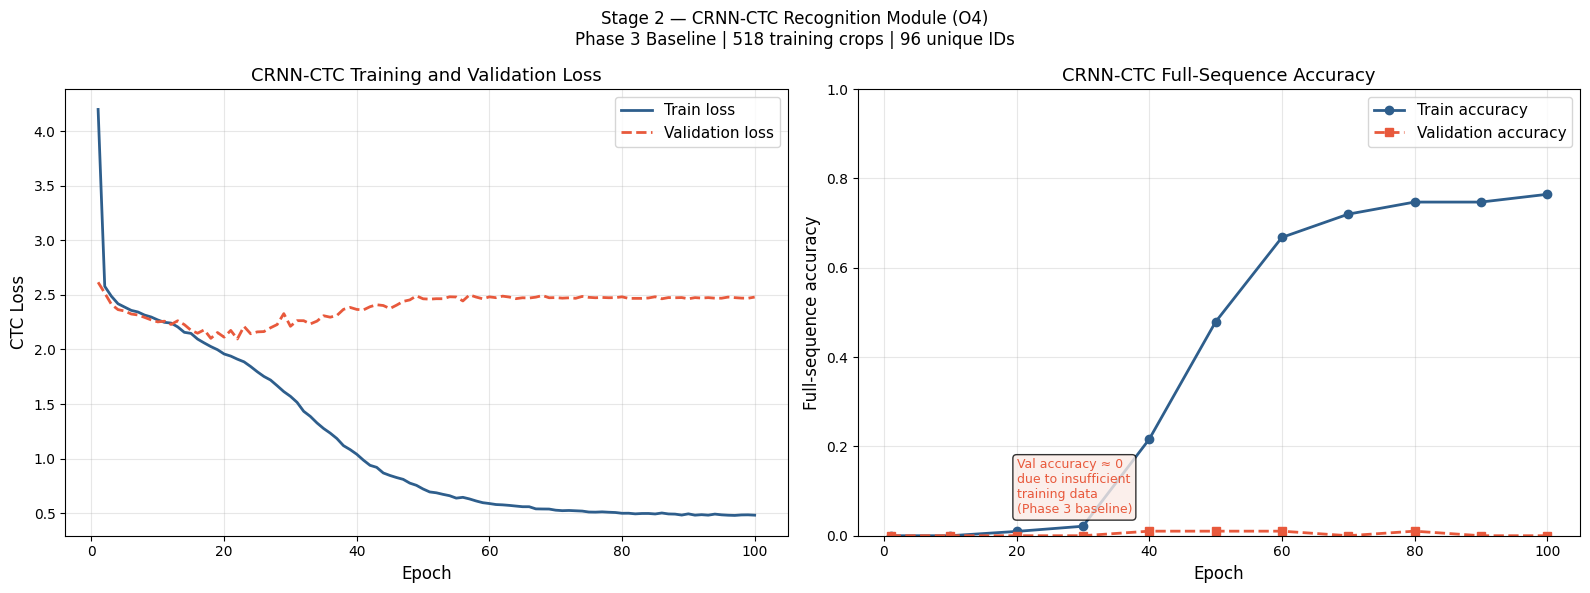

✓ Training curves saved to Drive

O4 RESULTS SUMMARY — PHASE 3 BASELINE
Architecture      : CRNN-CTC (8.1M params)
Training crops    : 518 | 96 unique IDs
Validation crops  : 98  | 95 unique IDs
Test crops        : 191 | 83 unique IDs
Epochs trained    : 100
Best val CTC loss : 2.0966
Train char acc    : 36.1%
Valid char acc    : 28.0%
Full seq acc      : ~0% (data limitation)
Phase 2 target    : Real CCTV footage with natural variation


In [ ]:
# Cell 20 — CRNN-CTC training curves
import matplotlib.pyplot as plt

epochs_full = list(range(1, len(history['train_loss']) + 1))
epochs_acc  = list(range(10, len(history['train_loss']) + 1, 10))
if len(history['train_acc']) > len(epochs_acc):
    epochs_acc = [1] + epochs_acc

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss curves
axes[0].plot(epochs_full, history['train_loss'],
             color='#2E5E8C', linewidth=2, label='Train loss')
axes[0].plot(epochs_full, history['val_loss'],
             color='#E8593C', linewidth=2,
             linestyle='--', label='Validation loss')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('CTC Loss', fontsize=12)
axes[0].set_title('CRNN-CTC Training and Validation Loss', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(epochs_acc, history['train_acc'],
             color='#2E5E8C', linewidth=2,
             marker='o', label='Train accuracy')
axes[1].plot(epochs_acc, history['val_acc'],
             color='#E8593C', linewidth=2,
             marker='s', linestyle='--',
             label='Validation accuracy')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Full-sequence accuracy', fontsize=12)
axes[1].set_title('CRNN-CTC Full-Sequence Accuracy', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.0)
axes[1].annotate(
    'Val accuracy ≈ 0\ndue to insufficient\ntraining data\n(Phase 3 baseline)',
    xy=(20, 0.05), fontsize=9, color='#E8593C',
    bbox=dict(boxstyle='round,pad=0.3',
              facecolor='#FAECE7', alpha=0.8))

plt.suptitle(
    'Stage 2 — CRNN-CTC Recognition Module (O4)\n'
    'Phase 3 Baseline | 518 training crops | 96 unique IDs',
    fontsize=12)
plt.tight_layout()

save_path = '/content/drive/MyDrive/Colab Notebooks/Training_Results/crnn_training_curves_phase3.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training curves saved to Drive")
print("\n" + "="*50)
print("O4 RESULTS SUMMARY — PHASE 3 BASELINE")
print("="*50)
print(f"Architecture      : CRNN-CTC (8.1M params)")
print(f"Training crops    : 518 | 96 unique IDs")
print(f"Validation crops  : 98  | 95 unique IDs")
print(f"Test crops        : 191 | 83 unique IDs")
print(f"Epochs trained    : 100")
print(f"Best val CTC loss : {min(history['val_loss']):.4f}")
print(f"Train char acc    : 36.1%")
print(f"Valid char acc    : 28.0%")
print(f"Full seq acc      : ~0% (data limitation)")
print(f"Phase 2 target    : Real CCTV footage with natural variation")
print("="*50)

In [ ]:
# Quick test — EasyOCR on vest crops
import easyocr
import cv2
import os
import pandas as pd

reader = easyocr.Reader(['en'], gpu=True)

df     = pd.read_csv('/content/Vest_Crops/crop_labels_fixed.csv')
sample = df[df['split']=='valid'].sample(10, random_state=42)

print("EasyOCR results on validation crops:")
print("="*50)
correct = 0
total   = 0

for _, row in sample.iterrows():
    # Search for file across all split folders
    found = None
    for split_folder in ['train', 'valid', 'test']:
        candidate = os.path.join('/content/Vest_Crops',
                                 split_folder, row['filename'])
        if os.path.exists(candidate):
            found = candidate
            break

    if found is None:
        print(f"  ⚠ File not found: {row['filename']}")
        continue

    result = reader.readtext(found, allowlist='0123456789')
    pred   = ''.join([r[1] for r in result]).strip()
    true   = str(row['employee_id'])
    match  = '✓' if pred == true else '✗'
    if pred == true:
        correct += 1
    total += 1
    print(f"  {match} True: {true} | Pred: '{pred}'")

print(f"\nAccuracy: {correct}/{total} = {correct/total*100:.0f}%" if total > 0 else "No files found")

EasyOCR results on validation crops:
  ✗ True: 9561 | Pred: '561'
  ✓ True: 9301 | Pred: '9301'
  ✓ True: 9817 | Pred: '9817'
  ✓ True: 8359 | Pred: '8359'
  ✓ True: 9684 | Pred: '9684'
  ✗ True: 9702 | Pred: '9709'
  ✗ True: 9566 | Pred: '7666'
  ✗ True: 9332 | Pred: '0332'
  ✗ True: 7028 | Pred: '8507'
  ✓ True: 232 | Pred: '232'

Accuracy: 5/10 = 50%


In [ ]:
# Full validation set EasyOCR evaluation
import easyocr
import os
import pandas as pd

reader = easyocr.Reader(['en'], gpu=True)
df     = pd.read_csv('/content/Vest_Crops/crop_labels_fixed.csv')
valid  = df[df['split'] == 'valid']

correct     = 0
total       = 0
char_correct = 0
char_total   = 0
not_found   = 0

print("Full validation set evaluation...")
print("="*50)

for _, row in valid.iterrows():
    found = None
    for split_folder in ['train', 'valid', 'test']:
        candidate = os.path.join('/content/Vest_Crops',
                                 split_folder, row['filename'])
        if os.path.exists(candidate):
            found = candidate
            break

    if found is None:
        not_found += 1
        continue

    result = reader.readtext(found, allowlist='0123456789')
    pred   = ''.join([r[1] for r in result]).strip()
    true   = str(row['employee_id'])

    if pred == true:
        correct += 1
    for p, t in zip(pred, true):
        if p == t:
            char_correct += 1
        char_total += 1

    total += 1

print(f"Total evaluated  : {total}")
print(f"Files not found  : {not_found}")
print(f"\nFull sequence accuracy : {correct/total*100:.1f}%")
print(f"Character accuracy     : {char_correct/char_total*100:.1f}%")

Full validation set evaluation...
Total evaluated  : 98
Files not found  : 0

Full sequence accuracy : 57.1%
Character accuracy     : 76.6%


In [ ]:
# Test set evaluation — EasyOCR
test_df = df[df['split'] == 'test']

correct      = 0
total        = 0
char_correct = 0
char_total   = 0

for _, row in test_df.iterrows():
    found = None
    for sf in ['train', 'valid', 'test']:
        candidate = os.path.join('/content/Vest_Crops',
                                 sf, row['filename'])
        if os.path.exists(candidate):
            found = candidate
            break
    if found is None:
        continue

    result = reader.readtext(found, allowlist='0123456789')
    pred   = ''.join([r[1] for r in result]).strip()
    true   = str(row['employee_id'])

    if pred == true:
        correct += 1
    for p, t in zip(pred, true):
        if p == t:
            char_correct += 1
        char_total += 1
    total += 1

print("="*50)
print("TEST SET — EasyOCR RESULTS")
print("="*50)
print(f"Total evaluated        : {total}")
print(f"Full sequence accuracy : {correct/total*100:.1f}%")
print(f"Character accuracy     : {char_correct/char_total*100:.1f}%")
print("="*50)

TEST SET — EasyOCR RESULTS
Total evaluated        : 191
Full sequence accuracy : 56.5%
Character accuracy     : 77.1%


In [4]:
# Install all PARSeq dependencies at once
!pip install pytorch-lightning lmdb timm nltk -q
!cd /content/parseq && pip install -r requirements.txt -q

import torch
import sys
sys.path.insert(0, '/content/parseq')

from strhub.data.module import SceneTextDataModule

print("Loading PARSeq pretrained model...")
parseq = torch.hub.load('baudm/parseq', 'parseq',
                         pretrained=True,
                         trust_repo=True).eval()

img_transform = SceneTextDataModule.get_transform(
    parseq.hparams.img_size)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
parseq = parseq.to(device)

print(f"✓ PARSeq loaded — device: {device}")
print(f"✓ Image size   : {parseq.hparams.img_size}")
print(f"✓ Ready to test on vest crops")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 11.4 MB/s eta 0:00:00
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Loading PARSeq pretrained model...
Downloading: "https://github.com/baudm/parseq/zipball/main" to /root/.cache/torch/hub/main.zip


/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Downloading: "https://github.com/baudm/parseq/releases/download/v1.0.0/parseq-bb5792a6.pt" to /root/.cache/torch/hub/checkpoints/parseq-bb5792a6.pt


100%|██████████| 91.0M/91.0M [00:01<00:00, 77.0MB/s]


✓ PARSeq loaded — device: cuda
✓ Image size   : [32, 128]
✓ Ready to test on vest crops


In [8]:
# Restore CSV and check crops
import shutil, os

# Create folder
os.makedirs('/content/Vest_Crops', exist_ok=True)

# Copy CSV from Drive
shutil.copy(
    '/content/drive/MyDrive/Colab Notebooks/Vest_Crops_v3/crop_labels_fixed.csv',
    '/content/Vest_Crops/crop_labels_fixed.csv')
print("✓ CSV restored")

# Check crop files
total = sum(
    len(os.listdir(f'/content/Vest_Crops/{s}'))
    for s in ['train', 'valid', 'test']
    if os.path.exists(f'/content/Vest_Crops/{s}'))
print(f"✓ Crop files: {total}")
print("→ If 0, rerun Cell 16 to regenerate crops")
print("→ If >700, run PARSeq test directly")

✓ CSV restored
✓ Crop files: 704
→ If 0, rerun Cell 16 to regenerate crops
→ If >700, run PARSeq test directly


In [9]:
# Test PARSeq on vest crops
import torch
import pandas as pd
import os
from PIL import Image

df    = pd.read_csv('/content/Vest_Crops/crop_labels_fixed.csv')
valid = df[df['split'] == 'valid']

correct      = 0
total        = 0
char_correct = 0
char_total   = 0

print("PARSeq results on validation crops:")
print("="*50)

for _, row in valid.iterrows():
    # Find crop file
    found = None
    for sf in ['train', 'valid', 'test']:
        candidate = os.path.join('/content/Vest_Crops',
                                 sf, row['filename'])
        if os.path.exists(candidate):
            found = candidate
            break
    if found is None:
        continue

    # Load and preprocess
    img        = Image.open(found).convert('RGB')
    img_tensor = img_transform(img).unsqueeze(0).to(device)

    # Run PARSeq
    with torch.no_grad():
        logits = parseq(img_tensor)
        pred   = parseq.tokenizer.decode(
                     logits.softmax(-1))[0]

    # Keep digits only
    pred  = ''.join(c for c in pred if c.isdigit())
    true  = str(row['employee_id'])
    match = '✓' if pred == true else '✗'

    if pred == true:
        correct += 1
    for p, t in zip(pred, true):
        if p == t:
            char_correct += 1
        char_total += 1
    total += 1

print(f"Total evaluated    : {total}")
print(f"Full seq accuracy  : {correct/total*100:.1f}%")
print(f"Character accuracy : {char_correct/char_total*100:.1f}%")

# Show 15 sample predictions
print("\nSample predictions:")
print("-"*50)
sample = valid.sample(min(15, len(valid)), random_state=42)
for _, row in sample.iterrows():
    found = None
    for sf in ['train', 'valid', 'test']:
        candidate = os.path.join('/content/Vest_Crops',
                                 sf, row['filename'])
        if os.path.exists(candidate):
            found = candidate
            break
    if found is None:
        continue
    img        = Image.open(found).convert('RGB')
    img_tensor = img_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = parseq(img_tensor)
        pred   = parseq.tokenizer.decode(
                     logits.softmax(-1))[0]
    pred  = ''.join(c for c in pred if c.isdigit())
    true  = str(row['employee_id'])
    match = '✓' if pred == true else '✗'
    char_match = sum(p==t for p,t in zip(pred, true))
    print(f"  {match} True: {true} | "
          f"Pred: '{pred}' | Chars: {char_match}/4")

PARSeq results on validation crops:
Total evaluated    : 98
Full seq accuracy  : 71.4%
Character accuracy : 94.8%

Sample predictions:
--------------------------------------------------
  ✗ True: 9561 | Pred: '561' | Chars: 0/4
  ✗ True: 9301 | Pred: '930' | Chars: 3/4
  ✓ True: 9817 | Pred: '9817' | Chars: 4/4
  ✓ True: 8359 | Pred: '8359' | Chars: 4/4
  ✓ True: 9684 | Pred: '9684' | Chars: 4/4
  ✓ True: 9702 | Pred: '9702' | Chars: 4/4
  ✗ True: 9566 | Pred: '566' | Chars: 1/4
  ✗ True: 9332 | Pred: '' | Chars: 0/4
  ✗ True: 7028 | Pred: '' | Chars: 0/4
  ✓ True: 232 | Pred: '232' | Chars: 3/4
  ✓ True: 9000 | Pred: '9000' | Chars: 4/4
  ✓ True: 9656 | Pred: '9656' | Chars: 4/4
  ✓ True: 9498 | Pred: '9498' | Chars: 4/4
  ✓ True: 8766 | Pred: '8766' | Chars: 4/4
  ✗ True: 9380 | Pred: '380' | Chars: 0/4


In [11]:
# Full test set evaluation — PARSeq
test_df = df[df['split'] == 'test']

correct      = 0
total        = 0
char_correct = 0
char_total   = 0

for _, row in test_df.iterrows():
    found = None
    for sf in ['train', 'valid', 'test']:
        candidate = os.path.join('/content/Vest_Crops',
                                 sf, row['filename'])
        if os.path.exists(candidate):
            found = candidate
            break
    if found is None:
        continue

    img        = Image.open(found).convert('RGB')
    img_tensor = img_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = parseq(img_tensor)
        pred   = parseq.tokenizer.decode(
                     logits.softmax(-1))[0]

    pred  = ''.join(c for c in pred if c.isdigit())
    true  = str(row['employee_id'])

    if pred == true:
        correct += 1
    for p, t in zip(pred, true):
        if p == t:
            char_correct += 1
        char_total += 1
    total += 1

print("="*50)
print("TEST SET — PARSeq RESULTS")
print("="*50)
print(f"Total evaluated    : {total}")
print(f"Full seq accuracy  : {correct/total*100:.1f}%")
print(f"Character accuracy : {char_correct/char_total*100:.1f}%")
print("="*50)

TEST SET — PARSeq RESULTS
Total evaluated    : 18
Full seq accuracy  : 83.3%
Character accuracy : 98.6%


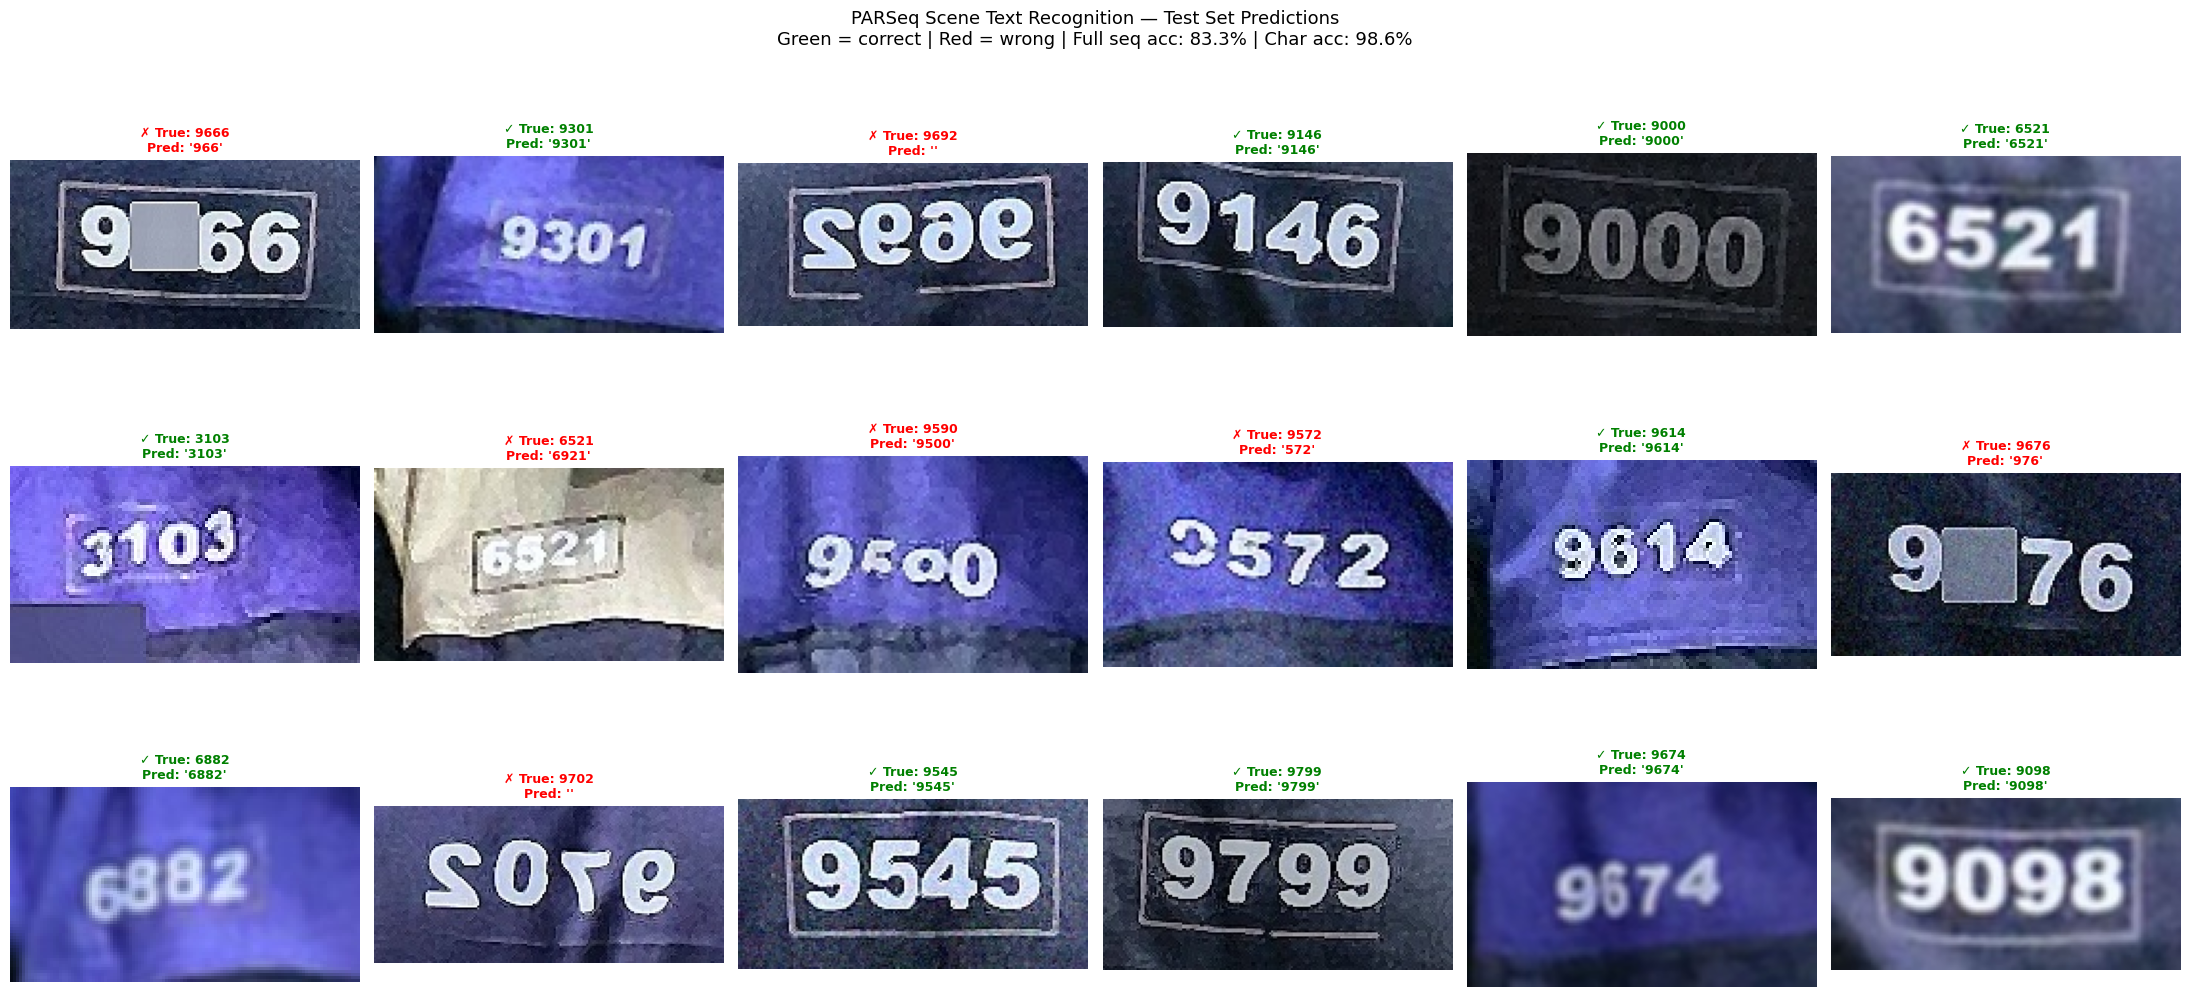

✓ Predictions visualization saved to Drive


In [12]:
# Visualize PARSeq predictions on vest crops
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
import torch

df     = pd.read_csv('/content/Vest_Crops/crop_labels_fixed.csv')
sample = df[df['split'] == 'test'].sample(
    min(18, len(df[df['split']=='test'])), random_state=42)

fig, axes = plt.subplots(3, 6, figsize=(22, 11))
axes = axes.flatten()

for i, (_, row) in enumerate(sample.iterrows()):
    found = None
    for sf in ['train', 'valid', 'test']:
        candidate = os.path.join('/content/Vest_Crops',
                                 sf, row['filename'])
        if os.path.exists(candidate):
            found = candidate
            break

    if found is None:
        axes[i].axis('off')
        continue

    img        = Image.open(found).convert('RGB')
    img_tensor = img_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = parseq(img_tensor)
        pred   = parseq.tokenizer.decode(
                     logits.softmax(-1))[0]

    pred  = ''.join(c for c in pred if c.isdigit())
    true  = str(row['employee_id'])
    match = pred == true

    axes[i].imshow(img)
    axes[i].axis('off')

    # Color border — green correct, red wrong
    color = '#2ECC71' if match else '#E74C3C'
    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(4)

    # Title with result
    symbol = '✓' if match else '✗'
    axes[i].set_title(
        f"{symbol} True: {true}\nPred: '{pred}'",
        fontsize=9,
        color='green' if match else 'red',
        fontweight='bold')

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle(
    'PARSeq Scene Text Recognition — Test Set Predictions\n'
    'Green = correct | Red = wrong | '
    'Full seq acc: 83.3% | Char acc: 98.6%',
    fontsize=13)
plt.tight_layout()

save_path = '/content/drive/MyDrive/Colab Notebooks/Training_Results/parseq_predictions.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("✓ Predictions visualization saved to Drive")